In [3]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import os
from pysr import PySRRegressor
from scipy.optimize import curve_fit
import sympy as sp

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Preprocess data

## Functions used in preprocessing

In [4]:
def parse_experiment_data(file_path):
    """
    Parses the experiment data file and extracts the experiment number, date, 
    and time series with values for each sample.
    
    Args:
        file_path (str): Path to the experiment data file.
    
    Returns:
        dict: Parsed data in the format:
            {
                "num": experiment_number,
                "date": date_collected,
                "samples": {
                    "Sample001": {"time": [times], "values": [values]},
                    ...
                }
            }
    """
    parsed_data = {}

    try:
        with open(file_path, "r") as file:
            lines = file.readlines()
        
        # Extract the experiment number
        experiment_line = lines[0].strip()
        match = re.search(r"(?:rate|mads_t)(\d+)\.rre", experiment_line, re.IGNORECASE)
        if match:
            parsed_data["num"] = int(match.group(1))
        else:
            parsed_data["num"] = None
            print("Warning: Experiment number not found.")

        # Extract the date
        if len(lines) > 5:
            date_line = lines[5].strip().split('\t')
            if len(date_line) > 1:
                parsed_data["date"] = date_line[1]
            else:
                parsed_data["date"] = None
                print("Warning: Date not found in the expected format.")
        else:
            parsed_data["date"] = None
            print("Warning: Date line is missing.")

        # Extract sample names (case-insensitive normalization)
        if len(lines) > 2:
            sample_names = lines[2].strip().split('\t')[1::2]
            normalized_sample_names = {sample.lower(): sample for sample in sample_names}
            parsed_data["samples"] = {normalized_sample_names[sample]: {"time": [], "values": []} 
                                      for sample in normalized_sample_names}
        else:
            parsed_data["samples"] = {}
            print("Warning: Sample names line is missing.")

        # Locate the start of the data section
        for i, line in enumerate(lines):
            if line.lower().startswith("ss.sss"):
                data_start_line = i + 1
                break
        else:
            raise ValueError("Data section not found in the file.")
        
        # Parse the data
        for line in lines[data_start_line:]:
            values = line.strip().split('\t')
            if not values or len(values) < 2:  # Skip empty or incomplete lines
                continue
            try:
                time = float(values[0])  # Extract time from the first column
            except ValueError:
                print(f"Warning: Invalid time value in line: {line}")
                continue

            for i, sample in enumerate(normalized_sample_names):
                value_index = 2 * i + 1  # Locate the corresponding value column
                if value_index < len(values):  # Check if the value exists
                    try:
                        value = float(values[value_index])
                        parsed_data["samples"][normalized_sample_names[sample]]["time"].append(time)
                        parsed_data["samples"][normalized_sample_names[sample]]["values"].append(value)
                    except ValueError:
                        print(f"Warning: Invalid value for {sample} in line: {line}")
                        continue

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"Error: An unexpected error occurred: {e}")
        return None

    return parsed_data


In [5]:

def resample_time_series_with_offset(time, values, interval=60, plot=False):
    """
    Resamples a time series to a uniform time step using cubic spline interpolation,
    adjusts the values to start at 0, and plots the original data, fitted spline,
    and resampled points. If the second time value equals the interval, assumes the
    series already has the correct time step and skips resampling.
    
    Args:
        time (list or array): Original time points.
        values (list or array): Original values corresponding to time points.
        interval (int): Desired uniform time step in seconds.
        plot (bool): Whether to plot the results.
        
    Returns:
        dict: Resampled time series with keys 'Time' and 'Values'.
    """
    # Convert to numpy arrays for compatibility
    time = np.array(time)
    values = np.array(values)
    # Check if the time step matches the desired interval
    if len(time) > 1 and np.isclose(time[1] - time[0], interval):
        # Apply offset directly without resampling
        value_offset = values[0]
        adjusted_values = values - value_offset
        
        if plot:
            # Plot the results
            plt.figure(figsize=(10, 6))
            plt.plot(time, adjusted_values, 'o', label="Original Data (Offset Applied)", markersize=4)
            plt.xlabel("Time (seconds)")
            plt.ylabel("Values (Offset)")
            plt.title("Time Series with Offset Applied (No Resampling Needed)")
            plt.legend()
            plt.grid(True)
            plt.show()
        
        return {"time": time, "values": adjusted_values}
    
    # Generate new time points at uniform intervals starting from the first time
    start_time = time[0]
    new_time = np.arange(start_time, time[-1] + interval, interval)

    # exclude the last time point if it is greater than the last time point in the original data
    if new_time[-1] > time[-1]:
        new_time = new_time[:-1]
    
    # Fit a cubic spline to the original data
    spline = CubicSpline(time, values)
    
    # Evaluate the spline at the new time points
    new_values = spline(new_time)
    
    # Apply the offset (subtract the value at the first new time point)
    value_offset = new_values[0]
    # value_offset = min(new_values)
    new_values -= value_offset
    
    if plot:
        # Plot the results
        plt.figure(figsize=(10, 6))
        plt.plot(time, values, 'o', label="Original Data", markersize=4)
        plt.plot(new_time, new_values, 'x', label="Resampled Points (Offset)", markersize=4)
        plt.xlabel("Time (seconds)")
        plt.ylabel("Values (Offset)")
        plt.title("Time Series Resampling with Spline Interpolation (Offset Applied)")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # Return the resampled time and values
    return {"time": new_time, "values": new_values}


In [6]:

def find_and_parse_experiment_file(experiment_number, directory, sheet_name=None):
    """
    Finds the associated .xls file for a given experiment number by searching recursively
    through subdirectories starting from the provided path and parses the specified sheet.
    If the primary method fails, uses the #num pattern as a fallback.
    
    Args:
        experiment_number (int): The experiment number to search for (e.g., 26 for mads_t026).
        directory (str): The directory where the search starts.
        sheet_name (str, optional): Name of the sheet to parse. If None, the first sheet is used.
    
    Returns:
        tuple: A tuple containing the filename and a DataFrame with the parsed data, 
               or None if no file is found.
    """
    # Primary pattern for mads_t<num> or rate<num>
    primary_pattern = re.compile(rf"(mads_t|rate){experiment_number:03d}.*\.xls", re.IGNORECASE)
    # Fallback pattern for #<num>
    fallback_pattern = re.compile(rf"#\s*{experiment_number}\.xls", re.IGNORECASE)
    
    # Search recursively for files
    for file in Path(directory).rglob("*.xls"):
        # Check for primary pattern first
        if primary_pattern.search(file.name):
            try:
                return parse_file(file, sheet_name)
            except Exception as e:
                print(f"Error parsing file {file}: {e}")
                return None
    
    # If no file is found using the primary pattern, use the fallback pattern
    for file in Path(directory).rglob("*.xls"):
        if fallback_pattern.search(file.name):
            try:
                return parse_file(file, sheet_name)
            except Exception as e:
                print(f"Error parsing file {file}: {e}")
                return None
    
    # If no file is found
    print(f"No file found for experiment number {experiment_number}.")
    return None


def parse_file(file, sheet_name=None):
    """
    Parses the specified .xls file.
    
    Args:
        file (Path): Path to the file.
        sheet_name (str, optional): Name of the sheet to parse. If None, the first sheet is used.
    
    Returns:
        tuple: A tuple containing the filename and a DataFrame with the parsed data.
    """
    # Read the .xls file without headers
    if sheet_name:
        # Read the specified sheet
        data = pd.read_excel(file, sheet_name=sheet_name, header=None)
    else:
        # Read the entire file and default to the first sheet
        df = pd.read_excel(file, sheet_name=None, header=None)  # Load all sheets
        print(f"Available sheets: {list(df.keys())}")
        first_sheet_name = list(df.keys())[0]
        data = df[first_sheet_name]

    # Drop empty rows and columns
    # data = data.dropna(how="all", axis=1)  # Drop empty columns
    # data = data.dropna(how="all", axis=0)  # Drop empty rows
    
    return file.name, data




In [7]:
def find_header_row(data, search_strings=None):
    """
    Locates the header row in a given DataFrame by searching for any of the specified strings
    with exact matches, disregarding capitalization.

    Args:
        data (pd.DataFrame): The DataFrame to search through.
        search_strings (list of str): List of strings to search for in the cells.

    Returns:
        int: Index of the header row, or None if no match is found.
    """
    if search_strings is None:
        search_strings = ["[Enz]", "Kuv.", "[Enz] mmol/l", "sub"]  # Default strings to search for

    # Convert the list of search strings to lowercase for case-insensitive matching
    search_strings = [s.lower() for s in search_strings]

    # Iterate through rows of the DataFrame
    for i, row in data.iterrows():
        # Check if any cell matches any search string exactly (case-insensitive)
        if any(str(cell).strip().lower() in search_strings for cell in row):
            return i
    
    # If no match is found
    print(f"Header row containing one of {search_strings} not found.")
    return None


In [8]:
def find_numeric_values_below_header(data, header_row, sample_num):
    """
    Searches the header row for specific strings (case-insensitive), and for each match,
    finds the first 'sample_num' numeric values below the header row in the corresponding columns.
    Special fallback for [buf] searches the row below the header for strings containing 'buf'.
    Maps the found values to standardized keys: [enz], [h2o2], [sub], and [buf].
    If multiple matches exist, selects values from the column with the largest first numeric value.
    The values are rounded to 3 decimal places. For [buf], adjusts values using (number_in_cell / 2) * 100.

    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        header_row (int): The index of the header row.
        sample_num (int): The number of numeric values to include.
    
    Returns:
        dict: A dictionary with standardized keys ([enz], [h2o2], [sub], [buf]) and lists of rounded
              numeric values as values.
    """
    results = {"[enz]": None, "[h2o2]": None, "[sub]": None, "[buf]": None} 
    
    # Mapping of standardized keys to search terms
    search_mapping = {
        "[enz]": ["[enz]", "enz"],
        "[h2o2]": ["[h2o2]", "h2o2"],
        "[sub]": ["[sub]", "sub"],
        "[buf]": ["[buf]", "[buffer]"]
    }
    
    # Extract the header row
    header = data.iloc[header_row]
    row_below_header = data.iloc[header_row + 1]

    # Iterate over the columns in the header
    for col in data.columns:
        cell_value = str(header[col]).lower()  # Convert to lowercase for case-insensitive comparison
        
        # Check if the cell contains any of the search terms
        for standardized_key, search_terms in search_mapping.items():
            if any(term in cell_value for term in search_terms):
                # Find numeric values below the header
                numeric_values = []
                for value in data[col].iloc[header_row + 1:]:
                    if isinstance(value, (int, float)):
                        numeric_values.append(round(value, 3))
                    if len(numeric_values) == sample_num:
                        break
                
                if numeric_values:
                    # Store the values, prioritizing the column with the largest first value
                    if results[standardized_key] is None or numeric_values[0] > results[standardized_key][0]:
                        results[standardized_key] = numeric_values
    
    # Special fallback for [buf]
    if results["[buf]"] is None:
        for col in data.columns:
            cell_value_below = str(row_below_header[col]).lower()  # Row below header
            if "buf" in cell_value_below:
                numeric_values = []
                for value in data[col].iloc[header_row + 2:]:  # Search for numeric values below
                    if isinstance(value, (int, float)):
                        adjusted_value = round((value / 2) * 100, 3) # Here we assume the buffer is 100 mM
                        numeric_values.append(adjusted_value)
                    if len(numeric_values) == sample_num:
                        break
                if numeric_values:
                    results["[buf]"] = numeric_values
                    break
    
    # Set any None results to a list of zeros
    for key in results:
        if results[key] is None:
            results[key] = [0] * sample_num
    
    return results


In [9]:
def find_pH_value_in_range(data, row_range, col_range, filename=None):
    """
    Finds the pH value located in a cell to the immediate right of a cell containing the string "pH",
    within a specified range of rows and columns. If not found in the DataFrame, attempts to parse the 
    pH value from the filename using the patterns "pH=XX.XX" or "pH_XX,XX".
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the pH from as a fallback.
    
    Returns:
        float: The pH value if found and numeric, or None if not found or is NaN.
    """
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Iterate through the specified range
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1] - 1):  # Stop before the last column
            cell = search_area.iloc[row_index, col_index]
            # Match "pH" as a whole word
            if isinstance(cell, str) and re.fullmatch(r"\bpH\b", cell, re.IGNORECASE):
                # Check the cell to the right
                next_cell = search_area.iloc[row_index, col_index + 1]
                
                # Handle numeric types directly
                if isinstance(next_cell, float) and np.isnan(next_cell):
                    print("Adjacent cell contains NaN.")
                    return None
                if isinstance(next_cell, (int, float)):
                    return round(next_cell, 2)
                
                print(f"Adjacent value is not numeric: {next_cell}")
                print(filename)
                return None
    
    # If 'pH' is not found, attempt to parse from the filename
    if filename:
        # First pattern: pH=XX.XX
        match = re.search(r"pH=([\d.]+)", filename, re.IGNORECASE)
        if match:
            return round(float(match.group(1)), 2)
        
        # Second pattern: pH_XX,XX (comma as decimal separator)
        match = re.search(r"pH_([\d,]+)", filename, re.IGNORECASE)
        if match:
            pH_value = match.group(1).replace(",", ".")  # Convert comma to dot for float conversion
            return round(float(pH_value), 3)
        
        print("pH value not found in filename.")
    
    # If neither DataFrame nor filename contains pH information
    print("pH string not found in the specified range or filename.")
    return None


In [10]:
def find_temperature_value_in_range(data, row_range, col_range, filename=None):
    """
    Finds the temperature value located in a cell to the immediate right of a cell containing the string "T",
    within a specified range of rows and columns. If not found, searches for any cell in the range containing
    a string like "XX C" and extracts the numeric temperature value. If still not found, attempts to parse the
    temperature from the filename using the pattern "t=XX".
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the temperature from as a fallback.
    
    Returns:
        float: The temperature value if found and numeric, or None if not found.
    """
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # First attempt: Find "T" and get the adjacent cell
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1] - 1):  # Stop before the last column
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str) and re.fullmatch(r"\bT\b", cell, re.IGNORECASE):
                # Check the cell to the right
                next_cell = search_area.iloc[row_index, col_index + 1]
                
                # Handle numeric types directly
                if isinstance(next_cell, (int, float)):
                    return round(next_cell, 3)
                
                print(f"Adjacent value is not numeric: {next_cell}")
                return None
    
    # Fallback: Search for cells with "XX C" pattern directly in the range
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                match = re.search(r"(\d+(\.\d+)?)\s*C", cell, re.IGNORECASE)
                if match:
                    return int(match.group(1))
    
    # Fallback: Attempt to parse from the filename
    if filename:
        match = re.search(r"t=(\d+)", filename, re.IGNORECASE)
        if match:
            return int(match.group(1))
    
    # If no temperature information is found
    print("Temperature value not found in the specified range or filename.")
    return None

In [11]:
def find_buffer_type(data, row_range, col_range, filename=None, buffer_map=None):
    """
    Finds the buffer type within a specified range of rows and columns in a DataFrame.
    If not found in the DataFrame, attempts to parse the buffer type from the filename.
    Maps found buffer types to standardized names using a buffer_map.
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the buffer type from as a fallback.
        buffer_map (dict, optional): Mapping of buffer type keywords to standardized names.
    
    Returns:
        str: The standardized buffer type if found, or None if not found.
    """
    if buffer_map is None:
        buffer_map = {
            "boric": "Boric",
            "pyrophosphate": "Pyrophosphate",
            "phosphat": "Phosphate",
            "phosphate": "Phosphate",
            "Na4P2O7*10H2O" : "Pyrophosphate",
            "NaH2PO4*2H2O" : "Pyrophosphate",
            "carbonate": "Carbonate",
            "CO3": "Carbonate"
        }
    
    # Create a set of all keywords to search for (case-insensitive)
    keywords = {key.lower(): value for key, value in buffer_map.items()}
    
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Search the DataFrame for buffer types
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                cell_lower = cell.lower()
                for keyword, standardized_name in keywords.items():
                    if keyword in cell_lower:
                        return standardized_name
    
    # If no buffer type is found, attempt to parse from the filename
    if filename:
        filename_lower = filename.lower()
        for keyword, standardized_name in keywords.items():
            if keyword in filename_lower:
                return standardized_name
    
    # If neither DataFrame nor filename contains buffer type information
    print("Buffer type not found in the specified range or filename.")
    print(f"Filename: {filename}")
    return None


In [12]:
def find_substrate_type(data, row_range, col_range, filename=None):
    """
    Finds the substrate type within a specified range of rows and columns in a DataFrame.
    If not found in the DataFrame, attempts to parse the substrate type from the filename.
    Maps recognized substrate types to properly formatted values.
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the substrate type from as a fallback.
    
    Returns:
        str: The properly formatted substrate type if found, or an empty string if not found.
    """
    # Substrate types and their standardized mappings
    substrate_mapping = {
        "bnoh": "BnOH",
        "benzylalkohol": "BnOH",
        "4ome-bnoh": "4OMe-BnOH",
        "4-meo-bnoh": "4OMe-BnOH",
        "4-methoxy-benzylalkohol": "4OMe-BnOH"
    }
    
    # Convert mapping keys to lowercase for case-insensitive comparison
    search_terms = {key.lower(): value for key, value in substrate_mapping.items()}
    
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Search the DataFrame for substrate types
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                cell_lower = cell.lower()
                for term, standardized in search_terms.items():
                    # Match exact, start-of-string followed by whitespace, or whitespace-enclosed matches
                    if re.search(rf"(^|\s){re.escape(term)}(\s|$)", cell_lower):
                        return standardized
    
    # If no substrate type is found, attempt to parse from the filename
    if filename:
        filename_lower = filename.lower()
        for term, standardized in search_terms.items():
            if re.search(rf"(^|\s){re.escape(term)}(\s|$)", filename_lower):
                return standardized
    
    # If neither DataFrame nor filename contains substrate type information
    print("Substrate type not found in the specified range or filename.")
    print(f"Filename: {filename}")
    return ""


In [13]:
def populate_experimental_data_from_directory(directory, sheet_name='Sheet1'):
    """
    Populates a DataFrame with experimental data extracted from all experiment files in the directory.
    Additionally returns a list of all parsed_data objects.

    Args:
        directory (str): Directory containing both the experiment data files (.txt) and associated .xls files.
        sheet_name (str): Name of the sheet to parse in the .xls files.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: DataFrame containing the experimental data.
            - list: List of parsed_data objects from all text files.
    """
    # Initialize a list to hold rows of experimental data
    experiment_rows = []
    parsed_data_list = []  # To store all parsed_data objects

    # Substrate-specific properties
    substrate_properties = {
        "BnOH": {"abs": 285, "e": 1.23},
        "4OMe-BnOH": {"abs": 300, "e": 7.53},
    }

    # Find all text files in the directory
    text_files = [
        os.path.join(directory, file)
        for file in os.listdir(directory)
        if file.endswith(".txt")
    ]

    # Iterate through each experiment file
    for file_path in text_files:
        try:
            # Parse the experiment data
            parsed_data = parse_experiment_data(file_path)
            parsed_data_list.append(parsed_data)  # Add parsed_data to the list
            experiment_number = parsed_data["num"]

            # Locate and parse the associated .xls file
            file_name, experiment_data = find_and_parse_experiment_file(
                experiment_number=experiment_number,
                directory=directory,
                sheet_name=sheet_name
            )

            # Find relevant data in the .xls file
            header_row = find_header_row(experiment_data)
            initial_cons = find_numeric_values_below_header(
                experiment_data, header_row, sample_num=len(parsed_data['samples'])
            )
            pH_value = find_pH_value_in_range(experiment_data, (0, 100), (0, 100), filename=file_name)
            temperature = find_temperature_value_in_range(experiment_data, (0, 100), (0, 100), filename=file_name)
            buffer_type = find_buffer_type(experiment_data, (0, 100), (0, 100), filename=file_name)
            substrate_type = find_substrate_type(experiment_data, (0, 100), (0, 100), filename=file_name)

            # Fetch substrate-specific properties
            abs_value = substrate_properties.get(substrate_type, {}).get("abs", None)
            e_value = substrate_properties.get(substrate_type, {}).get("e", None)

            # Create a row for each sample
            for i, sample_name in enumerate(parsed_data['samples']):
                row = {
                    "experiment": experiment_number,
                    "sample": i + 1,
                    "substrate": substrate_type,
                    "abs": abs_value,
                    "e": e_value,
                    "buffer": buffer_type,
                    "pH": pH_value,
                    "T": temperature,
                    "[enz]": initial_cons["[enz]"][i] if initial_cons["[enz]"] else 0,
                    "[buf]": initial_cons["[buf]"][i] if initial_cons["[buf]"] else 0,
                    "[h2o2]": initial_cons["[h2o2]"][i] if initial_cons["[h2o2]"] else 0,
                    "[sub]": initial_cons["[sub]"][i] if initial_cons["[sub]"] else 0,
                }
                experiment_rows.append(row)
        
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            continue

    # Convert the list of rows into a DataFrame
    experiment_df = pd.DataFrame(experiment_rows)

    return experiment_df, parsed_data_list


In [14]:
def analyze_reaction_data(experiment_df):
    # Filter the DataFrame for catalyzed and uncatalyzed reactions
    catalyzed_df = experiment_df[experiment_df['[enz]'] > 0]
    uncatalyzed_df = experiment_df[experiment_df['[enz]'] == 0]

    # Continuous variables to plot
    columns = ['[enz]','[buf]', '[sub]', '[h2o2]', 'T', 'pH']
    titles = ["[Enz.]",'[Buf.]', "[Sub.]", "[H2O2]", "T (C)", "pH"]

    # Create a figure with side-by-side groups for catalyzed and uncatalyzed reactions
    # Dynamically create the correct grid size
    n_cols = len(columns)
    fig, axes = plt.subplots(4, n_cols, figsize=(n_cols * 2, 8))  # 4 rows for boxplots and histograms
    axes = axes.reshape(4, n_cols)  # Ensure axes has the right shape

    fig.suptitle("Continuous Data Analysis Grouped by Reaction Type", fontsize=20, y=1.02)  # Overall title

    for i, col in enumerate(columns):
        # Boxplot (Row 1)
        catalyzed_df[[col]].boxplot(ax=axes[0, i])
        axes[0, i].set_title(f"{titles[i]} (Cat.)")
        axes[0, i].set_ylabel("Value")
        axes[0, i].grid(True)

        # Histogram (Row 2)
        catalyzed_df[col].plot(kind='hist', bins=10, ax=axes[1, i], color='skyblue', edgecolor='black')
        axes[1, i].set_title(f"{titles[i]} (Cat.)")
        axes[1, i].set_xlabel("Value")
        axes[1, i].set_ylabel("Count")
        axes[1, i].grid(True)


    # Uncatalyzed reactions (Columns 1-5)
    for i, col in enumerate(columns):
        # Boxplot (Row 3)
        uncatalyzed_df[[col]].boxplot(ax=axes[2, i])
        axes[2, i].set_title(f"{titles[i]} (Uncat.)")
        axes[2, i].set_ylabel("Value")
        axes[2, i].grid(True)
        
        # Histogram (Row 4)
        uncatalyzed_df[col].plot(kind='hist', bins=10, ax=axes[3, i], color='skyblue', edgecolor='black')
        axes[3, i].set_title(f"{titles[i]} (Uncat.)")
        axes[3, i].set_xlabel("Value")
        axes[3, i].set_ylabel("Count")
        axes[3, i].grid(True)

    # Adjust layout for continuous data
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # To make room for the figure title
    plt.show()

    # Create a separate figure for categorical data
    fig_cat, axes_cat = plt.subplots(2, 2, figsize=(10, 10))  # 2 rows, 2 columns
    fig_cat.suptitle("Categorical Data Analysis Grouped by Reaction Type", fontsize=20, y=1.02)

    # Substrate distribution (Catalyzed)
    catalyzed_df['substrate'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[0, 0], 
        title="Substrate Distribution (Catalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[0, 0].set_ylabel("Count")
    axes_cat[0, 0].set_xlabel("Substrate Type")
    axes_cat[0, 0].grid(True)

    # Buffer distribution (Catalyzed)
    catalyzed_df['buffer'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[0, 1], 
        title="Buffer Distribution (Catalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[0, 1].set_ylabel("Count")
    axes_cat[0, 1].set_xlabel("Buffer Type")
    axes_cat[0, 1].grid(True)

    # Substrate distribution (Uncatalyzed)
    uncatalyzed_df['substrate'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[1, 0], 
        title="Substrate Distribution (Uncatalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[1, 0].set_ylabel("Count")
    axes_cat[1, 0].set_xlabel("Substrate Type")
    axes_cat[1, 0].grid(True)

    # Buffer distribution (Uncatalyzed)
    uncatalyzed_df['buffer'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[1, 1], 
        title="Buffer Distribution (Uncatalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[1, 1].set_ylabel("Count")
    axes_cat[1, 1].set_xlabel("Buffer Type")
    axes_cat[1, 1].grid(True)

    # Adjust layout for categorical data
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # To make room for the figure title
    plt.show()


In [15]:
def add_resampled_time_series_to_dataframe(
    experiment_df, 
    parsed_data_list, 
    interval=30, 
    plot=False, 
    noise_level=0.0, 
    cap=None
):
    """
    Adds a new column to the experimental DataFrame containing resampled time series 
    (converted to [P] vs time using the extinction coefficient) for each sample, 
    handling sample names case-insensitively. Optionally caps the resampled time series 
    to a maximum time value and adds random noise to the resampled data.

    Args:
        experiment_df (pd.DataFrame): The DataFrame containing experimental metadata.
        parsed_data_list (list): List of parsed_data objects from the text files.
        interval (int): Desired uniform time step in seconds for resampling (default: 30).
        plot (bool): Whether to plot the resampled [P] vs time for each sample (default: False).
        noise_level (float): Standard deviation of noise to be added to the resampled data, 
                             as a fraction of the range of the data (default: 0.0, no noise).
        cap (float): Maximum value of the time variable to retain in the resampled series (default: None).

    Returns:
        pd.DataFrame: The DataFrame with an additional column '[P]' containing
                      dictionaries of {'time': ..., 'values': ...}.
    """
    # Add a new column to store the resampled [P] time series
    resampled_series = []

    # Iterate through each row in the DataFrame
    for _, row in experiment_df.iterrows():
        experiment_num = row["experiment"]
        sample_num = row["sample"]
        extinction_coefficient = row["e"]  # Extinction coefficient for this experiment

        # Find the corresponding parsed data
        parsed_data = next(
            (p for p in parsed_data_list if p["num"] == experiment_num), None
        )

        if parsed_data:
            # Get the sample name (e.g., Sample001, Sample002, etc.) case-insensitively
            sample_key = f"sample{sample_num:03d}".lower()
            parsed_samples = {key.lower(): value for key, value in parsed_data["samples"].items()}

            if sample_key in parsed_samples:
                sample_data = parsed_samples[sample_key]
                time = sample_data["time"]
                values = sample_data["values"]

                # Resample the time series
                resampled_data = resample_time_series_with_offset(time, values, interval, plot)

                if resampled_data:
                    # Apply the time cap if specified
                    if cap is not None:
                        time_array = np.array(resampled_data["time"])
                        value_array = np.array(resampled_data["values"])
                        mask = time_array <= cap
                        time_array = time_array[mask]
                        value_array = value_array[mask]

                        resampled_data["time"] = time_array.tolist()
                        resampled_data["values"] = value_array.tolist()

                    # Convert absorbance values to [P] using Beer-Lambert Law: [P] = Abs / (e * pathlength)
                    # Assuming pathlength is 1 cm for simplicity
                    pathlength = 1.0
                    absorbance_values = np.array(resampled_data["values"])
                    concentration_values = absorbance_values / (extinction_coefficient * pathlength)

                    # Add random noise if requested
                    if noise_level > 0.0:
                        noise = np.random.normal(
                            scale=noise_level * (concentration_values.max() - concentration_values.min()), 
                            size=concentration_values.shape
                        )
                        concentration_values += noise

                    # Replace 'values' with [P] in the resampled data
                    resampled_data["values"] = concentration_values.tolist()

                    # Append the converted [P] vs time data
                    resampled_series.append(resampled_data)
                else:
                    resampled_series.append(None)
            else:
                print(f"Sample {sample_key} not found in experiment {experiment_num}.")
                resampled_series.append(None)
        else:
            print(f"Parsed data for experiment {experiment_num} not found.")
            resampled_series.append(None)

    # Add the resampled [P] vs time series to the DataFrame
    experiment_df["[P]"] = resampled_series

    return experiment_df


In [16]:
def add_parsed_time_series_to_dataframe(
    experiment_df, 
    parsed_data_list
):
    """
    Adds a new column to the experimental DataFrame containing parsed time series 
    (converted to [P] vs time using the extinction coefficient) for each sample, 
    handling sample names case-insensitively. Adjusts the data so that each progress
    curve starts at 0 (offset adjustment).

    Args:
        experiment_df (pd.DataFrame): The DataFrame containing experimental metadata.
        parsed_data_list (list): List of parsed_data objects from the text files.

    Returns:
        pd.DataFrame: The DataFrame with an additional column '[P]' containing
                      dictionaries of {'time': ..., 'values': ...}.
    """
    # Add a new column to store the parsed [P] time series
    parsed_series = []

    # Iterate through each row in the DataFrame
    for _, row in experiment_df.iterrows():
        experiment_num = row["experiment"]
        sample_num = row["sample"]
        extinction_coefficient = row["e"]  # Extinction coefficient for this experiment

        # Find the corresponding parsed data
        parsed_data = next(
            (p for p in parsed_data_list if p["num"] == experiment_num), None
        )

        if parsed_data:
            # Get the sample name (e.g., Sample001, Sample002, etc.) case-insensitively
            sample_key = f"sample{sample_num:03d}".lower()
            parsed_samples = {key.lower(): value for key, value in parsed_data["samples"].items()}

            if sample_key in parsed_samples:
                sample_data = parsed_samples[sample_key]
                time = sample_data["time"]
                values = sample_data["values"]

                # Convert absorbance values to [P] using Beer-Lambert Law: [P] = Abs / (e * pathlength)
                # Assuming pathlength is 1 cm for simplicity
                pathlength = 1.0
                absorbance_values = np.array(values)
                concentration_values = absorbance_values / (extinction_coefficient * pathlength)

                # Adjust [P] so that the curve starts at 0
                offset = concentration_values[0]  # Take the first value as the offset
                concentration_values -= offset

                # Replace 'values' with offset-adjusted [P] in the parsed data
                parsed_data_dict = {
                    "time": time,
                    "values": concentration_values.tolist()
                }

                # Append the converted and offset-adjusted [P] vs time data
                parsed_series.append(parsed_data_dict)
            else:
                print(f"Sample {sample_key} not found in experiment {experiment_num}.")
                parsed_series.append(None)
        else:
            print(f"Parsed data for experiment {experiment_num} not found.")
            parsed_series.append(None)

    # Add the parsed [P] vs time series to the DataFrame
    experiment_df["[P]"] = parsed_series

    return experiment_df


## Populate data frame with experimental dat

In [17]:
# Populate the DataFrame
data_df, parsed_data = populate_experimental_data_from_directory(directory="data/data")
# export the data to a csv file
data_df.to_csv("data/experiment_data.csv", index=False)
data_df.head()
#analyze_reaction_data(experiment_df)

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],[h2o2],[sub]
0,146,1,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,10.816
1,146,2,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,3.028
2,146,3,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,0.865
3,146,4,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,0.216
4,146,5,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,24.964,10.816


In [18]:
# find experimnt 18
data_df[data_df['[buf]'] == 0]

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],[h2o2],[sub]


In [19]:
# Add resampled time series to the DataFrame
from numpy import add


data_df_resampled = add_resampled_time_series_to_dataframe(data_df, parsed_data, interval=30, plot=False, noise_level=0.00, cap=10000) 
data_df = add_parsed_time_series_to_dataframe(data_df, parsed_data)

# Inspect the resulting DataFrame
data_df_resampled.head(10)
len(data_df_resampled)
data_df

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],[h2o2],[sub],[P]
0,146,1,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,10.816,"{'time': [0.0, 60.0, 120.0, 180.0, 240.0, 300...."
1,146,2,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,3.028,"{'time': [0.0, 60.0, 120.0, 180.0, 240.0, 300...."
2,146,3,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,0.865,"{'time': [0.0, 60.0, 120.0, 180.0, 240.0, 300...."
3,146,4,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,35.244,0.216,"{'time': [0.0, 60.0, 120.0, 180.0, 240.0, 300...."
4,146,5,BnOH,285,1.23,Pyrophosphate,8.66,25,0.021,75.013,24.964,10.816,"{'time': [0.0, 60.0, 120.0, 180.0, 240.0, 300...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,127,4,4OMe-BnOH,300,7.53,Pyrophosphate,7.29,25,0.032,193.637,3.879,9.470,"{'time': [0.0, 31.0, 62.0, 93.0, 124.0, 155.0,..."
439,22,1,4OMe-BnOH,300,7.53,Phosphate,6.50,25,0.241,80.000,82.500,1.850,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."
440,22,2,4OMe-BnOH,300,7.53,Phosphate,6.50,25,0.241,70.000,82.500,3.700,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."
441,22,3,4OMe-BnOH,300,7.53,Phosphate,6.50,25,0.241,60.000,82.500,5.549,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."


In [20]:
len(data_df_resampled)

443

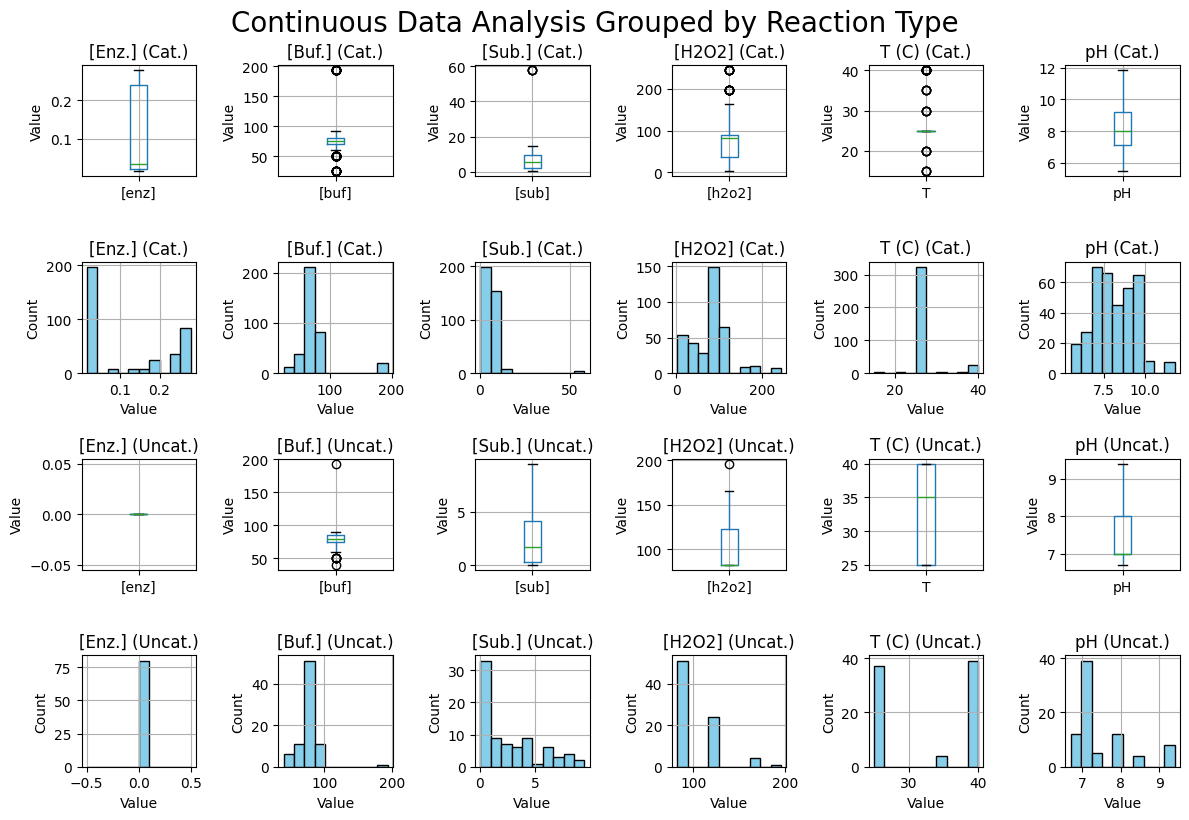

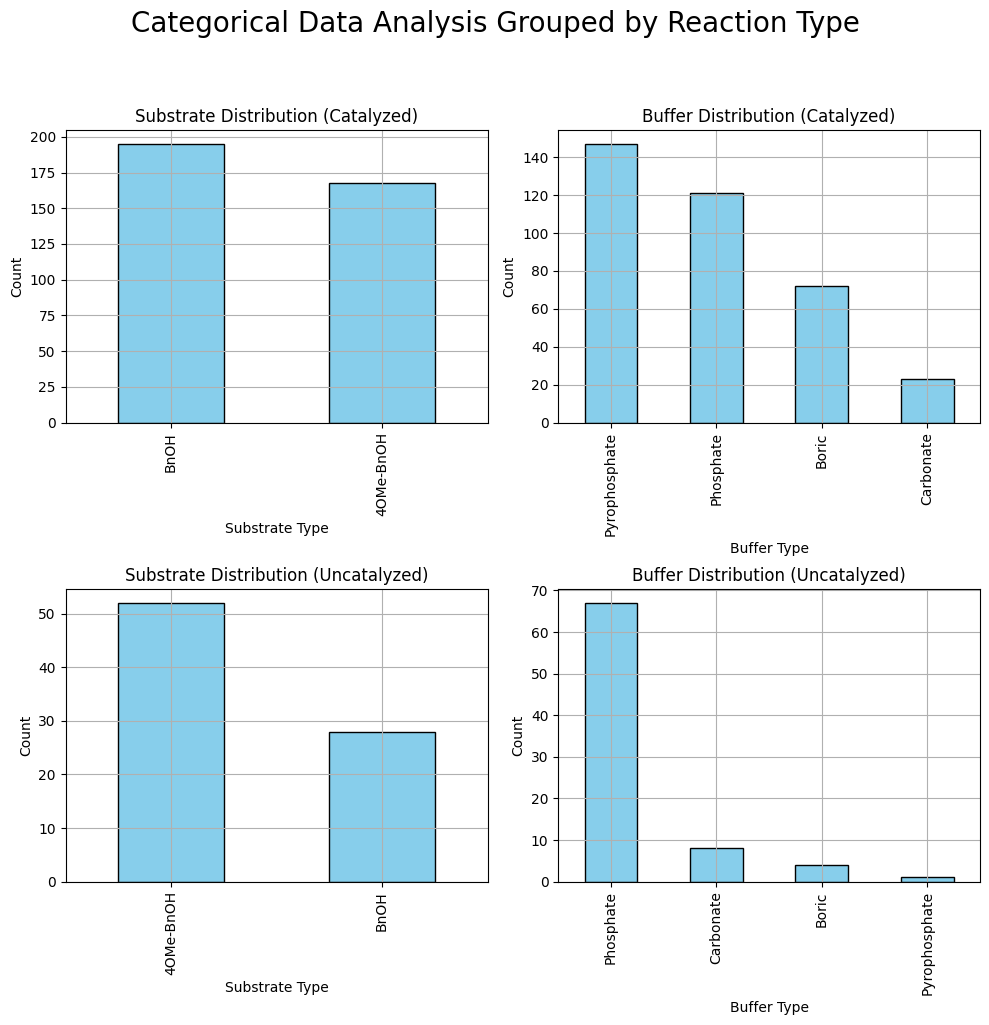

In [21]:
analyze_reaction_data(data_df_resampled)

## Clean data experimental data

In [22]:
# Correct the signs for the [P] values in experiment in thg following experiments. It looks like Sample and reference cuvette were swapped during the experiment.
experiment_to_correct = [50, 85]

for exp_num in experiment_to_correct:
    for idx, row in data_df_resampled[data_df_resampled["experiment"] == exp_num].iterrows():
        if isinstance(row["[P]"], dict) and "time" in row["[P]"] and "values" in row["[P]"]:
            # Flip the signs of the 'values' in the '[P]' dictionary
            data_df_resampled.at[idx, "[P]"]["values"] = [-v for v in row["[P]"]["values"]]


# Fix [buf] for experiment 34
buf_values_exp34 = [50, 25, 12.5, 6.25]
for i, idx in enumerate(data_df_resampled[data_df_resampled["experiment"] == 34].index):
    data_df_resampled.at[idx, "[buf]"] = buf_values_exp34[i]

# Fix [buf] for experiments 35 and 36
buf_values_exp35_36 = [100, 200, 300, 400]
for i, idx in enumerate(data_df_resampled[data_df_resampled["experiment"] == 35].index):
    data_df_resampled.at[idx, "[buf]"] = buf_values_exp35_36[i]
for i, idx in enumerate(data_df_resampled[data_df_resampled["experiment"] == 36].index):
    data_df_resampled.at[idx, "[buf]"] = buf_values_exp35_36[i]


# remove the following experiments from the data
# 84 is missing data, is 58 cuvettes appears swapped and reversed. 77 and 78 look very strange, negative rate but sample and reference cuvette do not appear to be swapped.
experiments_to_remove =[84, 58, 77, 78, 79]
for exp_num in experiments_to_remove:
    data_df_resampled = data_df_resampled[data_df_resampled["experiment"] != exp_num]

# Remove the following experiment-sample pairs from the data
exp_num_sample_num = [[128, 2], [128, 3]]
for exp_num, sample_num in exp_num_sample_num:
    data_df_resampled = data_df_resampled[~((data_df_resampled["experiment"] == exp_num) & (data_df_resampled["sample"] == sample_num))]

# remove all corbonate buffer experiments
data_df_resampled = data_df_resampled[data_df_resampled["buffer"] != "Carbonate"]

# Fit progress curves

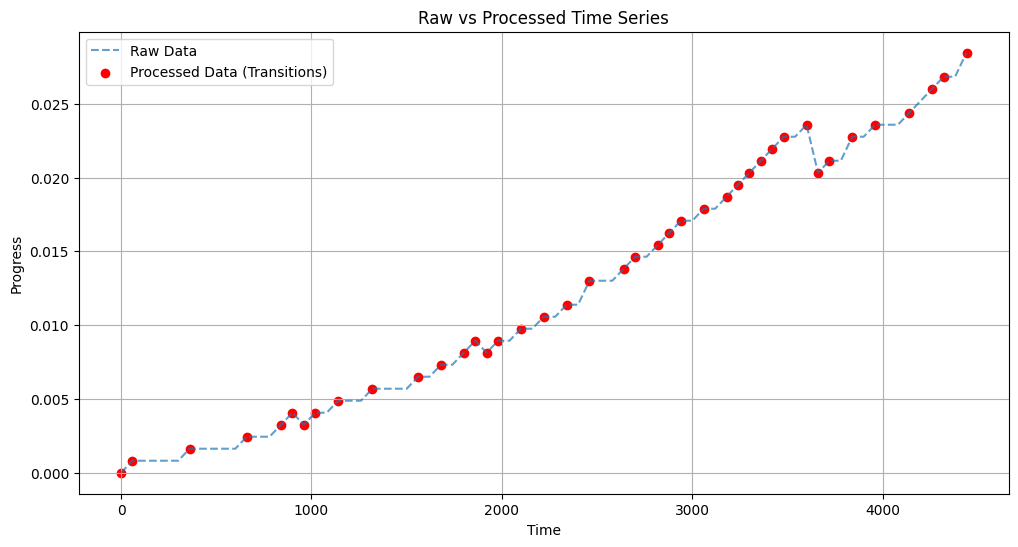

In [301]:
from scipy.stats import mode
import numpy as np

def preprocess_time_series(t, P, threshold=None, plot=False, use_original=False):
    """
    Preprocess a time series to compute useful metrics for change point detection.
    
    Parameters:
        t (array-like): Time points of the time series.
        P (array-like): Progress values of the time series.
        threshold (float, optional): Threshold for detecting significant transitions.
                                      If None, it is computed dynamically.
        plot (bool): Whether to plot the raw and processed data. Default is False.
        use_original (bool): Whether to compute metrics on the original data. Default is False.
    
    Returns:
        dict: Processed time series and computed metrics.
    """
    # Ensure inputs are numpy arrays
    t = np.array(t)
    P = np.array(P)
    
    # Compute point-to-point changes
    point_changes = np.abs(np.diff(P, prepend=P[0]))
    
    # Determine dynamic threshold if not provided
    if threshold is None:
        threshold = np.percentile(point_changes[point_changes > 0], 5)  # 5th percentile
    
    # Identify transition indices based on the threshold
    transition_indices = [0] + [i for i in range(1, len(P)) if point_changes[i] >= threshold]
    
    # Extract corresponding times and progress values
    t_processed = t[transition_indices]
    P_processed = P[transition_indices]
    
    # Decide data for metrics
    data_for_metrics = P if use_original else P_processed
    changes_for_metrics = np.abs(np.diff(data_for_metrics, prepend=data_for_metrics[0]))
    
    # Compute additional metrics
    max_diff = np.max(changes_for_metrics)
    mean_diff = np.mean(changes_for_metrics)
    median_diff = np.median(changes_for_metrics)
    max_mean_ratio = max_diff / mean_diff if mean_diff > 0 else np.inf
    max_median_ratio = max_diff / median_diff if median_diff > 0 else np.inf
    
    # Compute other metrics
    metrics = {
        "threshold": threshold,
        "min_change": np.min(changes_for_metrics[changes_for_metrics > 0]),
        "mean_change": mean_diff,
        "variance_change": np.var(changes_for_metrics),
        "num_transitions": len(transition_indices),
        "segment_means": [np.mean(P[start:end]) for start, end in zip(transition_indices[:-1], transition_indices[1:])],
        "segment_variances": [np.var(P[start:end]) for start, end in zip(transition_indices[:-1], transition_indices[1:])],
        "baseline_value": mode(P, keepdims=True).mode[0],
        "max_diff": max_diff,
        "mean_diff": mean_diff,
        "median_diff": median_diff,
        "max_mean_ratio": max_mean_ratio,
        "max_median_ratio": max_median_ratio
    }
    
    # Plot if required
    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.plot(t, P, label="Raw Data", linestyle="--", alpha=0.7)
        plt.scatter(t_processed, P_processed, label="Processed Data (Transitions)", color="red")
        plt.title("Raw vs Processed Time Series")
        plt.xlabel("Time")
        plt.ylabel("Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # Return processed time series and metrics
    return t_processed, P_processed, metrics




# Example usage
expr = 141
expr = 136
expr = 12
# expr = 18
expr = 140
expr = 147
expr = 145
# expr = 47
# expr = 142
# expr = 55
# expr = 82
# expr = 131
P = np.array(data_df[(data_df['experiment'] == expr) & (data_df['sample'] == 2)].iloc[0]['[P]']['values'])
t = np.array(data_df[(data_df['experiment'] == expr) & (data_df['sample'] == 1)].iloc[0]['[P]']['time'])

# Process the example time series
# Processed data metrics
t_processed, P_processed, metrics = preprocess_time_series(t, P, use_original=False, plot=True)




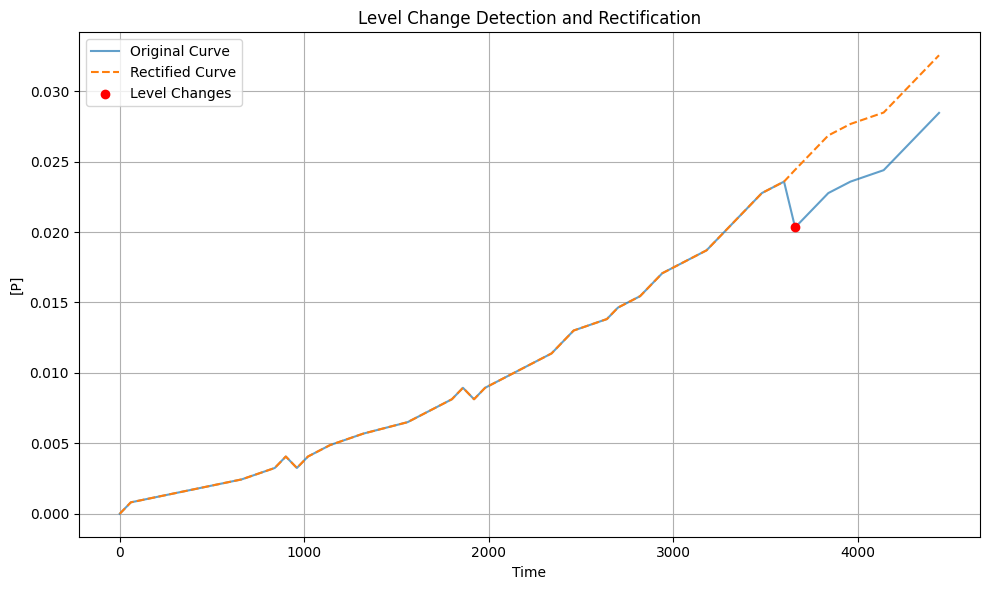

In [302]:
def detect_and_rectify_levels(t, P, threshold_factor=1.5, downward_changes_only=False, plot=False):
    """
    Detect level changes and rectify the curve by adjusting subsequent points.
    Optionally filter for downward changes only.
    
    Parameters:
        t (array-like): Time values of the time series.
        P (array-like): Progress values of the time series.
        threshold_factor (float): Factor to multiply the median difference for thresholding. Default is 1.5.
        downward_changes_only (bool): Whether to detect only downward level changes. Default is False.
        plot (bool): Whether to plot the results. Default is False.
    
    Returns:
        tuple:
            rectified_t (array-like): Time values for the rectified series.
            rectified_P (array-like): Rectified progress values.
            change_points (list): Detected level change points (time values).
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Ensure inputs are numpy arrays
    t = np.array(t)
    P = np.array(P)

    # Compute point-to-point differences
    diffs = np.diff(P)

    # Calculate the median difference and the dynamic threshold
    median_diff = np.median(np.abs(diffs))
    threshold = threshold_factor * median_diff

    # Detect where differences exceed the threshold
    if downward_changes_only:
        change_indices = np.where((diffs < 0) & (np.abs(diffs) > threshold))[0]
    else:
        change_indices = np.where(np.abs(diffs) > threshold)[0]

    # Convert indices to change points (time values)
    change_points = t[change_indices + 1]

    # Initialize the rectified curve
    P_rectified = np.copy(P)

    # Apply rectification starting from the first level change
    for i, idx in enumerate(change_indices):
        if idx < len(P) - 1:  # Ensure index is valid
            # Define the segment preceding the current change point
            if i == 0:
                prev_segment = P[:idx + 1]
            else:
                prev_segment = P[change_indices[i - 1] + 1 : idx + 1]

            # Calculate the median for the preceding segment
            if len(prev_segment) > 1:
                segment_median_diff = np.mean(np.abs(np.diff(prev_segment)))
            else:
                segment_median_diff = median_diff  # Handle small segments gracefully

            # Compute the adjustment
            diff = P[idx + 1] - P[idx]  # Difference at the level change
            adjustment = diff - segment_median_diff  # Incorporate the segment-specific median
            P_rectified[idx + 1:] -= adjustment  # Adjust all subsequent points

    # Plot if required
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(t, P, label="Original Curve", alpha=0.7)
        plt.plot(t, P_rectified, label="Rectified Curve", linestyle="--")
        plt.scatter(t[change_indices + 1], P[change_indices + 1], color="red", label="Level Changes", zorder=5)
        plt.title("Level Change Detection and Rectification")
        plt.xlabel("Time")
        plt.ylabel("[P]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return t, P_rectified, change_points

# Example usage
rectified_t, rectified_P, change_points = detect_and_rectify_levels(
    t_processed, P_processed, threshold_factor=1.5, downward_changes_only=True, plot=True
)


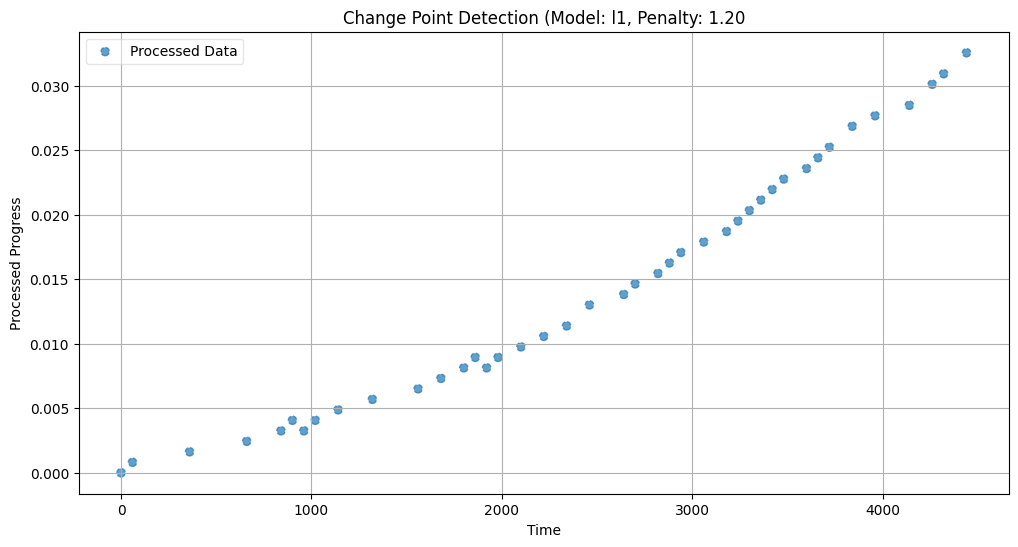

In [303]:
import ruptures as rpt

def detect_change_points(t_processed, P_processed, metrics, plot=False, base_penalty=0.05, model="rfb", min_size=10):
    """
    Detect change points in the processed time series using the ruptures library.
    
    Parameters:
        t_processed (array-like): Processed time points from the preprocessing step.
        P_processed (array-like): Processed progress values from the preprocessing step.
        metrics (dict): Metrics computed from the preprocessing step.
        plot (bool): Whether to plot the change point results. Default is False.
        method (str): Change point detection method ("Pelt" or "Binseg"). Default is "Pelt".
        base_penalty (float): Base penalty value for change point detection.
        model (str): Model type for change point detection. Default is "l1".
        min_size (int): Minimum size of segments. Default is 10.
    
    Returns:
        list: Detected change points (in time values) from the processed data.
    """
    # If the data is shorter than min_size, return start and end as breakpoints
    if len(t_processed) < min_size:
        print(f"Data length ({len(t_processed)}) is shorter than min_size ({min_size}). Returning start and end as breakpoints.")
        return [t_processed[0], t_processed[-1]]

    # Extract relevant metrics
    threshold = metrics["min_change"]  # Use threshold from preprocessing
    mean_change = metrics["mean_change"] / threshold
    variance_change = metrics["variance_change"] / threshold

    # Weights for combining metrics
    weight_mean = 1  # Adjust weight for mean_change
    weight_variance = 1  # Adjust weight for variance_change

    # Adjust penalty factor
    penalty_factor = (weight_mean * mean_change / (1 + weight_variance * variance_change))
    penalty = base_penalty * penalty_factor

    # Format the data for ruptures
    signal = np.array(P_processed).reshape(-1, 1)

    # Choose change point detection method
    algo = rpt.Pelt(model=model, min_size=min_size).fit(signal)

    # Detect change points
    bkps = algo.predict(pen=penalty)[:-1]  # Remove the last point (end of the signal)

    # Convert change points to time values
    change_points = [t_processed[bkp] for bkp in bkps]

    # Plot results if required
    if plot:
        plt.figure(figsize=(12, 6))
        plt.scatter(t_processed, P_processed, label="Processed Data", linestyle="--", alpha=0.7)
        for cp in change_points:
            plt.axvline(cp, color="red", linestyle="--", label=f"Change Point at {cp:.2f}")
        plt.title(f"Change Point Detection (Model: {model}, Penalty: {penalty:.2f}")
        plt.xlabel("Time")
        plt.ylabel("Processed Progress")
        plt.legend()
        legend = plt.gca().get_legend()
        legend.get_frame().set_alpha(0.5)
        plt.grid(True)
        plt.show()

    return change_points

# Example usage
change_points = detect_change_points(
    rectified_t,
    rectified_P,
    metrics,
    plot=True,
    model="l1",
    base_penalty=1.05,
    min_size=15
)


/tmp/ipykernel_258423/1559380311.py:23: RuntimeWarning: divide by zero encountered in power
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1559380311.py:23: RuntimeWarning: invalid value encountered in divide
  return P0 + (Vmax * t**n) / (K**n + t**n)


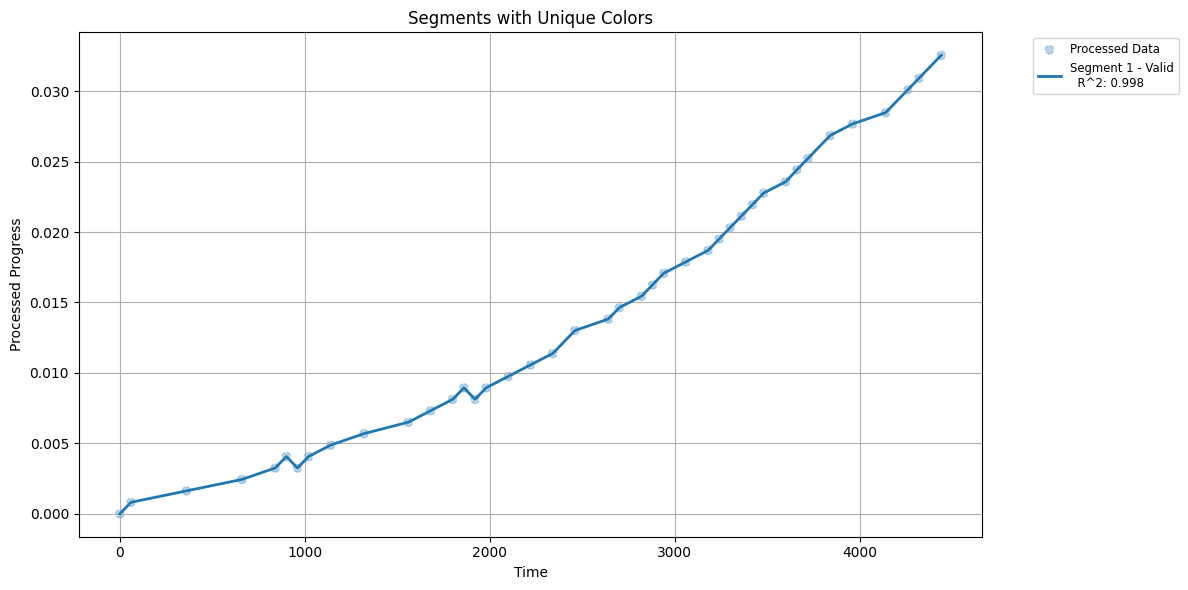

In [304]:
def identify_valid_segments(
    break_points, t_processed, P_processed, min_r2_threshold=0.9, plot=False
):
    """
    Identify valid segments for rate expression fitting based on \( R^2 \) evaluation.
    
    Parameters:
        break_points (list): List of breakpoints (time values) from the second function.
        t_processed (array-like): Time values from the processed time series.
        P_processed (array-like): Progress values from the processed time series.
        min_r2_threshold (float): Minimum \( R^2 \) value for a segment to be considered valid. Default is 0.9.
        plot (bool): Whether to plot the segments. Default is False.
    
    Returns:
        list: List of valid segments as tuples (t_segment, P_segment, validity metrics).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import curve_fit

    # Define the integrated Hill equation
    def integrated_hill(t, Vmax, K, n, P0):
        return P0 + (Vmax * t**n) / (K**n + t**n)

    valid_segments = []  # Store valid segments
    all_segments = []  # Store all segments with their validity and metrics

    # Add start and end points to breakpoints for segmentation
    break_points = [t_processed[0]] + break_points + [t_processed[-1]]

    # Iterate over each segment defined by consecutive breakpoints
    for i in range(len(break_points) - 1):
        # Extract the segment
        mask = (t_processed >= break_points[i]) & (t_processed <= break_points[i + 1])
        t_segment = t_processed[mask]
        P_segment = P_processed[mask]

        if len(t_segment) < 2 or len(P_segment) < 2:  # Skip very short segments
            continue

        # Fit an integrated Hill equation
        try:
            p0 = [np.max(P_segment), np.median(t_segment), 1.0, np.min(P_segment)]
            params, _ = curve_fit(integrated_hill, t_segment, P_segment, p0=p0, maxfev=50000)
            P_fit = integrated_hill(t_segment, *params)
            residuals = P_segment - P_fit
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((P_segment - np.mean(P_segment))**2)
            r2 = 1 - (ss_res / ss_tot)
        except RuntimeError:
            r2 = -np.inf  # Mark as invalid if fit fails

        # Determine if the segment is valid
        is_valid = r2 >= min_r2_threshold

        # Store segment information
        all_segments.append((t_segment, P_segment, is_valid, {"r2": r2}))

        # Add to valid segments if valid
        if is_valid:
            valid_segments.append((t_segment, P_segment, {"r2": r2}))

    # Plot all segments with unique colors
    if plot:
        plt.figure(figsize=(12, 6))
        plt.scatter(t_processed, P_processed, label="Processed Data", alpha=0.3, linestyle="--")
        cmap = plt.colormaps["tab20"]  # Use the colormap

        for idx, (t_segment, P_segment, is_valid, metrics) in enumerate(all_segments):
            color = cmap(idx / len(all_segments))  # Normalize index for colormap
            label = (
                f"Segment {idx + 1} - {'Valid' if is_valid else 'Invalid'}\n"
                f"  R^2: {metrics['r2']:.3f}"
            )
            plt.plot(t_segment, P_segment, label=label, color=color, linewidth=2)

        plt.title("Segments with Unique Colors")
        plt.xlabel("Time")
        plt.ylabel("Processed Progress")
        plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize="small")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return valid_segments



valid_segments = identify_valid_segments(
    change_points, rectified_t,rectified_P, min_r2_threshold=0.90, plot=True
)

/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: divide by zero encountered in power
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: invalid value encountered in divide
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: divide by zero encountered in power
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: invalid value encountered in divide
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: divide by zero encountered in power
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: invalid value encountered in divide
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeWarning: divide by zero encountered in power
  return P0 + (Vmax * t**n) / (K**n + t**n)
/tmp/ipykernel_258423/1217793974.py:36: RuntimeW

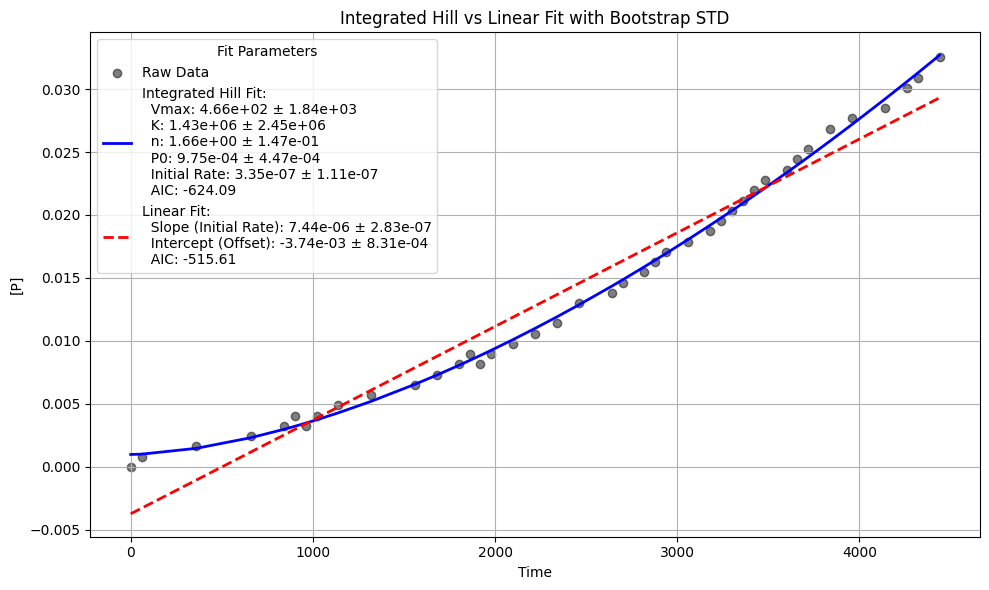

In [305]:
def fit_and_plot_integrated_hill(t, P, plot=True, n_bootstrap=100):
    """
    Fit and plot an integrated Hill equation and a linear fit for the given data segment.
    Perform bootstrap resampling using sklearn to estimate parameter uncertainties.
    
    Parameters:
        t (array-like): Time values of the valid segment.
        P (array-like): Progress curve values of the valid segment.
        plot (bool): Whether to plot the results. Default is True.
        n_bootstrap (int): Number of bootstrap samples. Default is 100.
    
    Returns:
        dict: Fitted parameters, AIC, offset values, and standard deviations for both models.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import curve_fit
    from sklearn.utils import resample
    from sklearn.linear_model import LinearRegression

    # Ensure inputs are numpy arrays
    t = np.array(t)
    P = np.array(P)

    if len(t) < 2 or len(P) < 2:
        raise ValueError("Data must contain at least two points for fitting.")

    # Centralize scaling
    t_min, t_scale = np.min(t), np.max(t) - np.min(t)
    P_scale = np.max(P)
    t_scaled = (t - t_min) / t_scale  # Scale time
    P_scaled = P / P_scale  # Scale progress

    # Define the integrated Hill equation
    def integrated_hill(t, Vmax, K, n, P0):
        return P0 + (Vmax * t**n) / (K**n + t**n)

    # Fit Integrated Hill Equation
    p0 = [np.max(P_scaled), np.median(t_scaled), 1.0, np.min(P_scaled)]  # Initial guesses
    try:
        params_hill, _ = curve_fit(
            integrated_hill,
            t_scaled,
            P_scaled,
            p0=p0,
            maxfev=50000
        )
    except RuntimeError as e:
        raise RuntimeError(f"Curve fitting failed: {e}")
    
    Vmax, K, n, P0 = params_hill
    P_pred_hill_scaled = integrated_hill(t_scaled, Vmax, K, n, P0)  # Scaled predictions
    P_pred_hill = P_pred_hill_scaled * P_scale  # Rescale predictions

    # Calculate initial rate for Integrated Hill numerically
    t_small = np.linspace(0, 0.01, 10)
    P_small_scaled = integrated_hill(t_small, Vmax, K, n, P0)
    initial_rate_hill_scaled = np.gradient(P_small_scaled, t_small).mean()
    initial_rate_hill = initial_rate_hill_scaled * (P_scale / t_scale)  # Rescale initial rate

    # Linear Fit
    lin_reg = LinearRegression()
    lin_reg.fit(t_scaled.reshape(-1, 1), P_scaled)
    slope_scaled, intercept_scaled = lin_reg.coef_[0], lin_reg.intercept_
    P_pred_linear_scaled = lin_reg.predict(t_scaled.reshape(-1, 1))  # Predictions in scaled space
    P_pred_linear = P_pred_linear_scaled * P_scale  # Rescale to original space

    slope = slope_scaled * (P_scale / t_scale)  # Rescale slope
    intercept = intercept_scaled * P_scale  # Rescale intercept

    # Bootstrap Resampling
    hill_bootstrap, linear_bootstrap, initial_rate_bootstrap = [], [], []
    for _ in range(n_bootstrap):
        t_sample, P_sample = resample(t_scaled, P_scaled)
        try:
            params_bootstrap, _ = curve_fit(
                integrated_hill,
                t_sample,
                P_sample,
                p0=p0,
                maxfev=50000
            )
            hill_bootstrap.append(params_bootstrap)
            Vmax_bs, K_bs, n_bs, P0_bs = params_bootstrap
            P_small_bs = integrated_hill(t_small, Vmax_bs, K_bs, n_bs, P0_bs)
            initial_rate_bs = np.gradient(P_small_bs, t_small).mean()
            initial_rate_bootstrap.append(initial_rate_bs)
        except RuntimeError:
            continue

        lin_reg_bootstrap = LinearRegression()
        lin_reg_bootstrap.fit(t_sample.reshape(-1, 1), P_sample)
        linear_bootstrap.append([lin_reg_bootstrap.coef_[0], lin_reg_bootstrap.intercept_])

    # Convert bootstrap results to arrays
    hill_bootstrap = np.array(hill_bootstrap)
    linear_bootstrap = np.array(linear_bootstrap)
    initial_rate_bootstrap = np.array(initial_rate_bootstrap)

    # Standard Deviations
    hill_std = np.std(hill_bootstrap, axis=0)
    linear_std = np.std(linear_bootstrap, axis=0)
    initial_rate_std = np.std(initial_rate_bootstrap)

    # Goodness-of-fit metrics
    residuals_hill = P - P_pred_hill
    ss_res_hill = np.sum(residuals_hill**2)
    aic_hill = len(t) * np.log(ss_res_hill / len(t)) + 2 * 4  # 4 parameters

    residuals_linear = P - P_pred_linear
    ss_res_linear = np.sum(residuals_linear**2)
    aic_linear = len(t) * np.log(ss_res_linear / len(t)) + 2 * 2  # 2 parameters

    # Legend Texts
    hill_text = (
        f"Integrated Hill Fit:\n"
        f"  Vmax: {Vmax * P_scale:.2e} ± {hill_std[0] * P_scale:.2e}\n"
        f"  K: {K * t_scale:.2e} ± {hill_std[1] * t_scale:.2e}\n"
        f"  n: {n:.2e} ± {hill_std[2]:.2e}\n"
        f"  P0: {P0 * P_scale:.2e} ± {hill_std[3] * P_scale:.2e}\n"
        f"  Initial Rate: {initial_rate_hill:.2e} ± {initial_rate_std * (P_scale / t_scale):.2e}\n"
        f"  AIC: {aic_hill:.2f}"
    )

    linear_text = (
        f"Linear Fit:\n"
        f"  Slope (Initial Rate): {slope:.2e} ± {linear_std[0] * (P_scale / t_scale):.2e}\n"
        f"  Intercept (Offset): {intercept:.2e} ± {linear_std[1] * P_scale:.2e}\n"
        f"  AIC: {aic_linear:.2f}"
    )

    # Plotting
    if plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(t, P, color='black', label="Raw Data", alpha=0.5)
        plt.plot(t, P_pred_hill, color='blue', label=hill_text, linewidth=2)
        plt.plot(t, P_pred_linear, color='red', label=linear_text, linestyle='--', linewidth=2)
        plt.xlabel("Time")
        plt.ylabel("[P]")
        plt.title("Integrated Hill vs Linear Fit with Bootstrap STD")
        plt.legend(loc="upper left", fontsize="medium", title="Fit Parameters")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Return Results
    return {
        "Integrated Hill": {
            "Vmax": Vmax * P_scale,
            "K": K * t_scale,
            "n": n,
            "P0": P0 * P_scale,
            "Initial Rate": initial_rate_hill,
            "STD": {
                "Vmax": hill_std[0] * P_scale,
                "K": hill_std[1] * t_scale,
                "n": hill_std[2],
                "P0": hill_std[3] * P_scale,
                "Initial Rate": initial_rate_std * (P_scale / t_scale)
            },
            "AIC": aic_hill
        },
        "Linear Fit": {
            "Slope": slope,
            "Intercept": intercept,
            "STD": {
                "Slope": linear_std[0] * (P_scale / t_scale),
                "Intercept": linear_std[1] * P_scale
            },
            "AIC": aic_linear
        }
    }




# Fit and plot the integrated Hill equation for each valid segment
t, P, r2 = valid_segments[0]
fits = fit_and_plot_integrated_hill(t, P, plot=True)


In [28]:
import matplotlib.cm as cm

def plot_v0_vs(
    dataframe,
    v0_vs,
    experiment_range=None,
    sample_range=None
):
    """
    Plots v0 values against a selected column in the DataFrame.

    Args:
        dataframe (pd.DataFrame): Input DataFrame containing 'v0' values.
        v0_vs (str): Column name to plot v0 against.
        experiment_range (tuple, optional): Range of experiments to include (start, end).
        sample_range (tuple, optional): Range of samples to include (start, end).

    Returns:
        None: Displays the scatter plot.
    """
    # Prepare lists for plotting
    v0_list = []
    x_values = []
    legends = []

    # Iterate over rows to extract filtered data
    for _, row in dataframe.iterrows():
        # Apply experiment and sample range filters
        if experiment_range and not (experiment_range[0] <= row["experiment"] <= experiment_range[1]):
            continue
        if sample_range and not (sample_range[0] <= row["sample"] <= sample_range[1]):
            continue

        # Ensure 'v0' and selected column are valid
        if row["v0"] is not None and pd.notnull(row[v0_vs]):
            v0_list.append(row["v0"])
            x_values.append(row[v0_vs])

            # Prepare legend entry
            legend_entry = (
                f"Exp {row['experiment']}, {row['sample']} | "
                f"{row['substrate']} | {row['buffer']} | "
                f"pH: {row['pH']:.2f} | {row['T']}°C | "
                f"[Enz]: {row['[enz]']:.3f} | [Buf]: {row['[buf]']:.3f} | [H2O2]: {row['[h2o2]']:.3f} | [Sub]: {row['[sub]']:.3f}"
            )
            legends.append(legend_entry)

    # Check if there is data to plot
    if not v0_list or not x_values:
        print("No valid data to plot.")
        return

    # Generate a colormap for unique colors
    num_points = len(v0_list)
    colors = cm.tab10(np.linspace(0, 1, num_points))

    # Create the scatter plot with unique colors
    plt.figure(figsize=(10, 6))
    for i in range(num_points):
        plt.scatter(x_values[i], v0_list[i], color=colors[i], label=legends[i])

    # Add plot details
    plt.xlabel(v0_vs)
    plt.ylabel("v0")
    plt.title(f"v0 vs {v0_vs}")
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.xlim(left=0)

    # Add legend
    plt.legend(
        bbox_to_anchor=(0.5, -0.2),  # Position below the plot
        loc='upper center',
        ncol=3  # 3 columns
    )
    plt.tight_layout()
    plt.show()


In [29]:

# do low pH fits
# fit_curves_to_data(
#     dataframe=data_df_resampled,
#     fit_range=(0, 8000),
#     # plot=True,
#     # experiment_range=(expr,expr),
#     # sample_range=(sample_low, sample_high),
#     pH_range=(0, 9),
#     noise_level=0.05
# )


# do high pH fits, high h2o2
# fit_curves_to_data(
#     dataframe=data_df_resampled,
#     fit_range=(0, 2000),
#     # plot=True,
#     # experiment_range=(expr,expr),
#     sample_range=(1, 4),
#     pH_range=(9.01,12),
#     noise_level=0.05
# )

# do high pH fits, low h2o2
# fit_curves_to_data(
#     dataframe=data_df_resampled,
#     fit_range=(0, 8000),
#     plot=True,
#     # experiment_range=(expr,expr),
#     sample_range=(5, 7),
#     pH_range=(9.01,12),
#     noise_level=0.05
# )

# do high pH fits, low h2o2
fitted_df = fit_curves_to_data(
    dataframe=data_df_resampled,
    fit_range=(0, 10000),

    plot=True,
    experiment_range=(11,11),
    # sample_range=(1, 4),
    # pH_range=(10, 15),
    noise_level=0.00
)
print(len(data_df_resampled))

plot_v0_vs(
    dataframe=fitted_df,
    v0_vs="[sub]",  # Column to plot v0 agaijnst
    experiment_range=(11, 11),
    # sample_range=(1, 4)
)
# pH < max_pH6 upper bound 10000, pH >= max_pH6 & pH < max_pH9 upper bound 2000, pH >= max_pH9 upper bound 1000

fitted_df
# naughty list [[exp_num, sample_num], ...]
# [[128,2], [128,3], [128,5], [137,6], [84,1]]

NameError: name 'fit_curves_to_data' is not defined

In [ ]:
# all experiments with R2
fitted_df[fitted_df['v0'] < 1e-8]

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],[h2o2],[sub],[P],fitted_function,v0,R2,fit_range
58,11,1,4OMe-BnOH,300,7.53,Phosphate,5.64,25,0.273,80.0,82.5,1.85,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0...",<function fit_curves_to_data.<locals>.<lambda>...,0.0,0.959005,"0, 9996.0"


In [ ]:
experimemnt = 9
sample_high = 4

plot_v0_vs(
    dataframe=fitted_df,
    v0_vs="[sub]",  # Column to plot v0 against
    experiment_range=(5, 5),
    # sample_range=(1, 1)
)
data_df_resampled[data_df_resampled["experiment"] == experimemnt]

No valid data to plot.


,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],[h2o2],[sub],[P]
151,9,1,4OMe-BnOH,300,7.53,Phosphate,5.67,25,0.175,80.0,82.5,1.850,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."
152,9,2,4OMe-BnOH,300,7.53,Phosphate,5.67,25,0.175,70.0,82.5,3.700,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."
153,9,3,4OMe-BnOH,300,7.53,Phosphate,5.67,25,0.175,60.0,82.5,5.549,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."
154,9,4,4OMe-BnOH,300,7.53,Phosphate,5.67,25,0.175,50.0,82.5,7.399,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0..."


In [ ]:
data_enzyme = fitted_df[fitted_df["[enz]"] != 0]
len(data_enzyme)
# onluy substrate BnOH
# data_enzyme = data_enzyme[data_enzyme["substrate"] == "BnOH"]
len(data_enzyme)

4

## Feature engenering.

In [ ]:
print(len(data_enzyme))
# print(data_enzyme.head())
relevant_features = ['pH', 'T', '[enz]', '[buf]', '[h2o2]', '[sub]','buffer']
summary = data_enzyme[relevant_features].describe()
print(summary)


4
         pH     T  [enz]      [buf]  [h2o2]     [sub]
count  4.00   4.0  4.000   4.000000     4.0  4.000000
mean   5.64  25.0  0.273  65.000000    82.5  4.624500
std    0.00   0.0  0.000  12.909944     0.0  2.387823
min    5.64  25.0  0.273  50.000000    82.5  1.850000
25%    5.64  25.0  0.273  57.500000    82.5  3.237500
50%    5.64  25.0  0.273  65.000000    82.5  4.624500
75%    5.64  25.0  0.273  72.500000    82.5  6.011500
max    5.64  25.0  0.273  80.000000    82.5  7.399000


In [ ]:
def add_ionic_strength_column(dataframe):
    """
    Adds an ionic strength column to the dataframe based on buffer type, pH, and [buf].

    Args:
        dataframe (pd.DataFrame): The input dataframe containing 'buffer', 'pH', and '[buf]'.

    Returns:
        pd.DataFrame: The dataframe with an added 'ionic_strength' column.
    """
    # Define dissociation constants (pKa values) for relevant buffers
    buffer_pKa = {
        'Phosphate': [2.15, 7.2, 12.35],  # pKa1, pKa2, pKa3 for phosphate
        'Pyrophosphate': [0.85, 1.96, 6.60, 9.41],  # pKa1, pKa2, pKa3, pKa4 for pyrophosphate
        'Boric Acid': [9.15],  # pKa for boric acid
    }

    def calculate_alpha(buffer, pH):
        """
        Calculate the fractional contributions of buffer species at the given pH.

        Args:
            buffer (str): Buffer type.
            pH (float): pH value.

        Returns:
            list: Fractional contributions of species in the buffer.
        """
        if buffer not in buffer_pKa:
            return [1]  # Assume a single species for unknown buffers

        pKa_values = buffer_pKa[buffer]
        H = 10 ** (-pH)
        alpha = [1]  # Start with the fully protonated form

        for pKa in pKa_values:
            alpha.append(alpha[-1] * (10 ** (-pKa) / H))

        alpha_sum = sum(alpha)
        return [a / alpha_sum for a in alpha]  # Normalize to get fractions

    def calculate_ionic_strength(row):
        """
        Calculate ionic strength based on buffer, pH, and buffer concentration.

        Args:
            row (pd.Series): A single row of the dataframe.

        Returns:
            float: Ionic strength for the row.
        """
        buffer = row['buffer']
        pH = row['pH']
        buf_concentration = row['[buf]']

        # Get fractional contributions
        alpha = calculate_alpha(buffer, pH)

        # Define charges for species (e.g., H3PO4 -> 0, H2PO4- -> -1, etc.)
        species_charges = {
            'Phosphate': [0, -1, -2, -3],
            'Pyrophosphate': [0, -1, -2, -3,-4],
            'Boric Acid': [0, -1],
        }

        charges = species_charges.get(buffer, [0])

        # Calculate ionic strength: I = 1/2 * sum(c * z^2)
        ionic_strength = 0.5 * buf_concentration * sum(alpha[i] * charges[i] ** 2 for i in range(len(alpha)))
        return ionic_strength

    # Create a new column for ionic strength
    dataframe = dataframe.copy()  # Avoid potential SettingWithCopyWarning
    dataframe.loc[:, 'I'] = dataframe.apply(calculate_ionic_strength, axis=1)

    return dataframe

updated_dataframe = add_ionic_strength_column(data_enzyme)
updated_dataframe[['buffer', 'pH', '[buf]', 'I']]



,buffer,pH,[buf],I
58,Phosphate,5.64,80.0,43.202881
59,Phosphate,5.64,70.0,37.802521
60,Phosphate,5.64,60.0,32.402161
61,Phosphate,5.64,50.0,27.001801


In [ ]:
def add_hooh_concentration_with_ionic_strength(dataframe):
    """
    Adds a feature for [HOO-] concentration based on [H2O2], pH, and ionic strength.

    Args:
        dataframe (pd.DataFrame): The input dataframe containing 'pH', '[h2o2]', and 'ionic_strength'.

    Returns:
        pd.DataFrame: The dataframe with an added '[HOO-]' column.
    """
    # Constants
    pKa_H2O2 = 11.75  # pKa of hydrogen peroxide at standard conditions
    A = 0.509  # Debye-Hückel constant for aqueous solutions at 25°C
    B = 0.328  # Constant for ionic strength adjustment
    z = -1     # Charge of HOO-

    def calculate_hooh_concentration(row):
        """
        Calculate the [HOO-] concentration for a single row.

        Args:
            row (pd.Series): A single row of the dataframe.

        Returns:
            float: Calculated [HOO-] concentration.
        """
        pH = row['pH']
        h2o2_concentration = row['[h2o2]']
        ionic_strength = row['I']

        # Adjust the pKa using the Debye-Hückel equation
        pKa_effective = pKa_H2O2 - (A * z**2 * np.sqrt(ionic_strength)) / (1 + B * np.sqrt(ionic_strength))

        # Calculate the fraction of HOO- using the Henderson-Hasselbalch equation
        fraction_hooh = 10 ** (pH - pKa_effective) / (1 + 10 ** (pH - pKa_effective))

        # Calculate [HOO-] as the fraction times the total H2O2 concentration
        hooh_concentration = fraction_hooh * h2o2_concentration
        return hooh_concentration

    # Apply the calculation to the dataframe and add a new column
    dataframe = dataframe.copy()  # Avoid modifying the original dataframe
    dataframe['[HOO-]'] = dataframe.apply(calculate_hooh_concentration, axis=1)

    return dataframe

updated_dataframe = add_hooh_concentration_with_ionic_strength(updated_dataframe)


In [ ]:
def add_custom_features(dataframe):
    """
    Adds custom features to the dataframe:
    - [sub]/[h2o2]
    - [enz]*[sub]*[h2o2]

    Args:
        dataframe (pd.DataFrame): The input dataframe containing '[sub]', '[h2o2]', and '[enz]'.

    Returns:
        pd.DataFrame: The dataframe with added features.
    """
    # Ensure the dataframe is copied to avoid modifying the original
    dataframe = dataframe.copy()

    # Calculate [sub]/[h2o2]
    dataframe['[sub]/[h2o2]'] = dataframe['[sub]'] / dataframe['[h2o2]']

    # Calculate [enz]*[sub]*[h2o2]
    dataframe['[enz]*[sub]*[h2o2]'] = dataframe['[enz]'] * dataframe['[sub]'] * dataframe['[h2o2]']

    return dataframe

updated_dataframe = add_custom_features(updated_dataframe)

In [ ]:
updated_dataframe

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[buf],...,[sub],[P],fitted_function,v0,R2,fit_range,I,[HOO-],[sub]/[h2o2],[enz]*[sub]*[h2o2]
58,11,1,4OMe-BnOH,300,7.53,Phosphate,5.64,25,0.273,80.0,...,1.850,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0...",<function fit_curves_to_data.<locals>.<lambda>...,0.0,0.959005,"0, 9996.0",43.202881,0.000735,0.022424,41.666625
59,11,2,4OMe-BnOH,300,7.53,Phosphate,5.64,25,0.273,70.0,...,3.700,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0...",<function fit_curves_to_data.<locals>.<lambda>...,0.0,0.988035,"0, 9996.0",37.802521,0.000698,0.044848,83.333250
60,11,3,4OMe-BnOH,300,7.53,Phosphate,5.64,25,0.273,60.0,...,5.549,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0...",<function fit_curves_to_data.<locals>.<lambda>...,0.0,0.989327,"0, 9996.0",32.402161,0.000656,0.067261,124.977353
61,11,4,4OMe-BnOH,300,7.53,Phosphate,5.64,25,0.273,50.0,...,7.399,"{'time': [0.0, 49.0, 98.0, 147.0, 196.0, 245.0...",<function fit_curves_to_data.<locals>.<lambda>...,0.0,0.991579,"0, 9996.0",27.001801,0.000609,0.089685,166.643978


In [ ]:
from pyexpat import features
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


def train_random_forest(dataframe):
    """
    Train a Random Forest model on enzymatic rate data.

    Args:
        dataframe (pd.DataFrame): Input dataframe containing features and target.

    Returns:
        dict: Dictionary containing evaluation metrics (MSE and R2) and the trained model.
    """
    # Define feature and target columns
    features = ['substrate', 'pH', 'T', '[enz]',
                '[h2o2]', '[sub]', 'I', '[HOO-]', '[enz]*[sub]*[h2o2]', '[sub]/[h2o2]']
    target = 'v0'

    # Separate features and target
    X = dataframe[features]
    y = dataframe[target]

    # One-hot encode categorical features
    categorical_features = ['substrate']
    X_encoded = pd.get_dummies(X, columns=categorical_features)
    print(X_encoded.columns)


    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.1, random_state=42)

    # Initialize the Random Forest model
    rf = RandomForestRegressor(
        n_estimators=2000,  # Number of trees
        max_depth=None,  # No maximum depth for trees
        min_samples_leaf=1,  # Minimum samples per leaf node
        random_state=42,  # Ensure reproducibility
        bootstrap=False,  # Use bootstrapping
        max_features='sqrt'  # Number of features to consider at each split

    )

    # Train the model
    rf.fit(X_train, y_train)

    # Predict on the test set
    y_pred = rf.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Print evaluation metrics
    print(f"Mean Squared Error (MSE): {mse:.4e}")
    print(f"R² Score: {r2:.4f}")

    # Return the model and metrics
    return {
        'model': rf,
        'mse': mse,
        'r2': r2
    }

# Example usage:
results = train_random_forest(updated_dataframe)
trained_model = results['model']
# get feature importances
importances = trained_model.feature_importances_
print(importances)

Index(['pH', 'T', '[enz]', '[h2o2]', '[sub]', 'I', '[HOO-]',
       '[enz]*[sub]*[h2o2]', '[sub]/[h2o2]', 'substrate_4OMe-BnOH'],
      dtype='object')


/home/madsr2d2/venvs/mat/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Mean Squared Error (MSE): 5.8230e-16
R² Score: nan
[0.         0.         0.         0.         0.20581796 0.19706006
 0.1893192  0.19904551 0.20875727 0.        ]


In [ ]:
# Define feature and target columns
features = ['substrate', 'pH', 'T', '[enz]', '[h2o2]', '[sub]', 'I', '[HOO-]', '[enz]*[sub]*[h2o2]', '[sub]/[h2o2]'] 
target = 'v0'

# Separate features and target
X = updated_dataframe[features]
y = updated_dataframe[target]

# One-hot encode categorical features
categorical_features = ['substrate']
X_encoded = pd.get_dummies(X, columns=categorical_features)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.1, random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [500, 1000, 2000],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Initialize a baseline Random Forest model
rf = RandomForestRegressor(random_state=42)

# Use GridSearchCV to tune hyperparameters
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Use MSE as scoring metric
    n_jobs=-1,  # Use all available CPU cores
    verbose=2
)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
print("Best MSE:", -grid_search.best_score_)

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predict on the test set
y_pred = best_rf.predict(X_test)

# Evaluate performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Set MSE: {mse:.4e}")
print(f"Test Set R²: {r2:.4f}")


NameError: name 'GridSearchCV' is not defined

In [ ]:
def generate_predictions_and_plot(model, dataframe, features, categorical_features, plot_feature=None):
    """
    Generate predictions using a trained Random Forest model and optionally plot the predictions.

    Args:
        model: Trained Random Forest model.
        dataframe (pd.DataFrame): New data for which predictions are required.
        features (list): List of feature column names.
        categorical_features (list): List of categorical feature column names.
        plot_feature (str, optional): Feature name to plot against the predicted values.

    Returns:
        pd.Series: Predictions for the input data.
    """
    # Select relevant features, including categorical features
    X = dataframe[features]

    # One-hot encode categorical features
    X_encoded = pd.get_dummies(X, columns=categorical_features)

    # Align columns with the training data
    X_encoded = X_encoded.reindex(columns=model.feature_names_in_, fill_value=0)

    # Generate predictions
    predictions = model.predict(X_encoded)
    predictions_series = pd.Series(predictions, index=dataframe.index)

    # Plot predictions if a feature is specified
    if plot_feature:
        if plot_feature in dataframe.columns:
            plt.figure(figsize=(10, 6))
            plt.scatter(dataframe[plot_feature], predictions, alpha=0.7, color='blue', label='Predictions')
            plt.xlabel(plot_feature)
            plt.ylabel('Predicted Values')
            plt.title(f'Predicted Values vs {plot_feature}')
            plt.grid(True)
            plt.ylim(bottom=0)
            plt.xlim(left=0)
            plt.legend()
            plt.show()
        else:
            print(f"Feature '{plot_feature}' not found in the dataframe.")

    return predictions_series


In [ ]:
ummary = data_enzyme[relevant_features].describe()
print(summary)

               pH           T       [enz]       [buf]      [h2o2]       [sub]
count  337.000000  337.000000  337.000000  337.000000  337.000000  337.000000
mean     7.993769   26.068249    0.121318   81.726300   75.254540    6.252196
std      1.163143    4.231202    0.112664   43.738865   41.760959    6.800265
min      5.470000   15.000000    0.014000    6.250000    2.447000    0.211000
25%      7.000000   25.000000    0.021000   70.000000   35.244000    2.062000
50%      8.010000   25.000000    0.034000   75.013000   82.500000    5.549000
75%      9.020000   25.000000    0.241000   80.000000   82.500000    9.470000
max     10.340000   40.000000    0.280000  400.000000  195.882000   57.900000


In [ ]:
def create_dataframe(
    substrate_range=(0.1, 10.0, 0.2),
    buffer="Pyrophosphate",
    substrate="BnOH",
    pH=7  ,
    temperature=25,
    enz_concentration=0.12,
    buffer_concentration=81.0,
    h2o2_concentration=75.0
):
    """
    Create a dataframe for predictions with specified ranges and fixed values for features.

    Args:
        substrate_range (tuple): Range for substrate concentration as (start, stop, step).
        buffer (str): Buffer type (e.g., 'Phosphate').
        substrate (str): Substrate name (e.g., 'BnOH').
        pH (float): pH value for all rows.
        temperature (float): Temperature (°C) for all rows.
        enz_concentration (float): Enzyme concentration [enz].
        buffer_concentration (float): Buffer concentration [buf].
        h2o2_concentration (float): H2O2 concentration [h2o2].

    Returns:
        pd.DataFrame: Generated dataframe.
    """
    # Generate substrate concentrations using the specified range
    sub_values = np.arange(*substrate_range)

    # Create the dataframe
    dataframe = pd.DataFrame({
        'substrate': [substrate] * len(sub_values),
        'buffer': [buffer] * len(sub_values),
        'pH': [pH] * len(sub_values),
        'T': [temperature] * len(sub_values),
        '[enz]': [enz_concentration] * len(sub_values),
        '[buf]': [buffer_concentration] * len(sub_values),
        '[h2o2]': [h2o2_concentration] * len(sub_values),
        '[sub]': sub_values
    })

    return dataframe

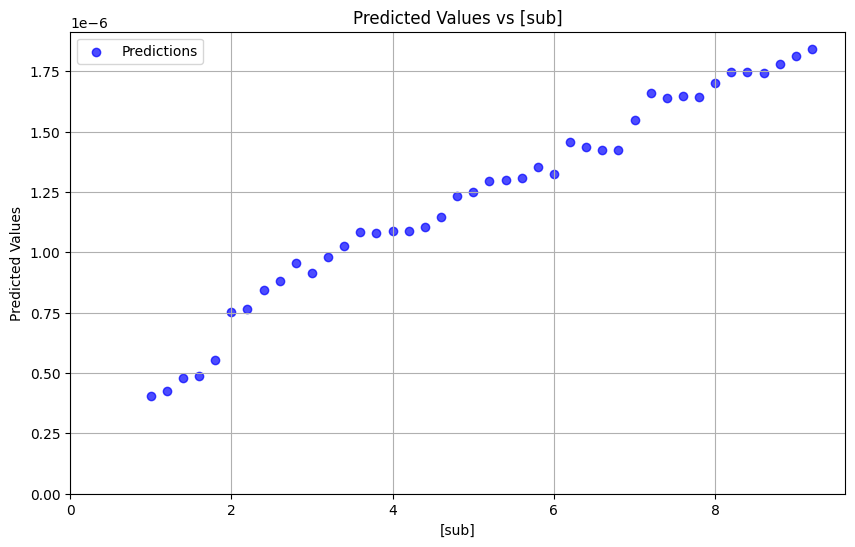

,substrate,pH,T,[enz],[h2o2],[sub],I,[HOO-],[sub]/[h2o2],[enz]*[sub]*[h2o2]
0,BnOH,6.9,25,0.12,75.0,1.0,297.613542,0.022065,0.013333,9.0
1,BnOH,6.9,25,0.12,75.0,1.2,297.613542,0.022065,0.016000,10.8
2,BnOH,6.9,25,0.12,75.0,1.4,297.613542,0.022065,0.018667,12.6
3,BnOH,6.9,25,0.12,75.0,1.6,297.613542,0.022065,0.021333,14.4
4,BnOH,6.9,25,0.12,75.0,1.8,297.613542,0.022065,0.024000,16.2
5,BnOH,6.9,25,0.12,75.0,2.0,297.613542,0.022065,0.026667,18.0
6,BnOH,6.9,25,0.12,75.0,2.2,297.613542,0.022065,0.029333,19.8
7,BnOH,6.9,25,0.12,75.0,2.4,297.613542,0.022065,0.032000,21.6
8,BnOH,6.9,25,0.12,75.0,2.6,297.613542,0.022065,0.034667,23.4
9,BnOH,6.9,25,0.12,75.0,2.8,297.613542,0.022065,0.037333,25.2


In [ ]:
# Define feature and categorical feature lists

features = ['substrate', 'pH', 'T', '[enz]',
            '[h2o2]', '[sub]', 'I', '[HOO-]', '[enz]*[sub]*[h2o2]', '[sub]/[h2o2]']
categorical_features = ['substrate']

# Generate a new dataframe for prediction
new_data = create_dataframe(substrate_range=(1, 9.4, 0.2))

# Add ionic strength, [HOO-], and custom features
new_data = add_ionic_strength_column(new_data)
new_data = add_hooh_concentration_with_ionic_strength(new_data)
new_data = add_custom_features(new_data)

# remove the buffer column 
new_data = new_data.drop(columns=['buffer'])
new_data = new_data.drop(columns=['[buf]'])


# # # Generate predictions and plot
predictions = generate_predictions_and_plot(
    model=trained_model,
    dataframe=new_data,
    features=features,
    categorical_features=categorical_features,
    plot_feature='[sub]'  # Specify the feature to plot against predictions
)
new_data

In [ ]:
def replace_numeric_constants(eq):
    """
    Replaces numeric constants in a symbolic equation with symbolic parameters.

    Args:
        eq (sympy.Expr): The symbolic equation.
results = discover_and_apply_time_function(
    dataframe=experiment_df,
    experiment_range=(146, 146),
    sample_range=(4, 4),
    time_range=(0, 50000),
    niterations=100,
    popsize=200,
    maxsize=7
)

# Updated DataFrame
updated_df = results["dataframe"]

    Returns:
        sympy.Expr: The equation with numeric constants replaced by parameters.
        list: List of symbolic parameters introduced.
    """
    constants = []
    constant_map = {}
    for num in eq.atoms(sp.Number):
        if num != 0:  # Exclude zero
            param = sp.symbols(f"param_{len(constants)}")
            constant_map[num] = param
            constants.append(param)
    eq_with_params = eq.subs(constant_map)
    return eq_with_params, constants


def discover_individual_time_functions(dataframe, experiment_range=None, sample_range=None, 
                                       time_range=None, niterations=40, popsize=50, maxsize=10):
    """
    Uses PySR to discover individual differentiable fitting functions for time-based [P](t) curves
    in the DataFrame and saves the refitted equations for each curve.

    Args:
        dataframe (pd.DataFrame): DataFrame containing experimental data, including [P](t) curves.
        experiment_range (tuple): Range of experiments to process (min_experiment, max_experiment).
                                  If None, processes all experiments.
        sample_range (tuple): Range of samples to process (min_sample, max_sample).
                              If None, processes all samples.
        time_range (tuple): Range of time points to include (min_time, max_time). If None, includes all time points.
        niterations (int): Number of optimization iterations for PySR.
        popsize (int): Population size for the genetic algorithm in PySR.
        maxsize (int): Maximum size of symbolic equations.

    Returns:
        pd.DataFrame: Updated DataFrame with a new column 'refitted_equation' containing individual fitted equations.
    """
    # Filter by experiment range if provided
    if experiment_range is not None:
        min_exp, max_exp = experiment_range
        dataframe = dataframe[(dataframe["experiment"] >= min_exp) & (dataframe["experiment"] <= max_exp)]
    
    # Filter by sample range if provided
    if sample_range is not None:
        min_sample, max_sample = sample_range
        dataframe = dataframe[(dataframe["sample"] >= min_sample) & (dataframe["sample"] <= max_sample)]

    # Initialize a column for storing individual equations
    refitted_equations = []

    # Iterate over each row to fit a unique equation to each curve
    for _, row in dataframe.iterrows():
        try:
            time_points = np.array(row["[P]"]["time"])  # Extract time points
            P_values = np.array(row["[P]"]["values"])  # Extract [P](t) values

            # Apply time range filter if specified
            if time_range is not None:
                min_time, max_time = time_range
                mask = (time_points >= min_time) & (time_points <= max_time)
                time_points = time_points[mask]
                P_values = P_values[mask]

            # Skip if no valid data points
            if len(time_points) == 0 or len(P_values) == 0:
                refitted_equations.append(None)
                continue

            # Define the PySR model
            model = PySRRegressor(
                niterations=niterations,
                binary_operators=["+", "-", "*", "/"],  # Basic operators
                unary_operators=["exp", "log", "sqrt"],  # Additional differentiable functions
                # extra_sympy_mappings={"exp": "exp"},  # Map "exp" to its symbolic representation
                loss="loss(x, y) = (x - y)^2",  # Mean squared error
                population_size=popsize,
                maxsize=maxsize,
                verbosity=0,  # Silence output for each individual fit
                random_state=42,
            )

            # Fit the model to the curve
            model.fit(time_points.reshape(-1, 1), P_values)

            # Extract the best equation and convert to symbolic form
            best_equation = model.get_best()["equation"]
            symbolic_equation = sp.sympify(best_equation)

            # Replace numeric constants in the equation with symbolic parameters
            parameterized_equation, constants = replace_numeric_constants(symbolic_equation)

            # Refit the parameterized equation to the individual curve
            x = sp.symbols("x0")  # Symbolic variable for time
            func = sp.lambdify((x, *constants), parameterized_equation, modules="numpy")

            # Fit the parameterized symbolic equation to the data
            initial_guess = [1.0] * len(constants)
            params, _ = curve_fit(lambda t, *params: func(t, *params), time_points, P_values, p0=initial_guess)

            # Generate the refitted equation by substituting fitted parameters
            refitted_eq = parameterized_equation.subs({c: p for c, p in zip(constants, params)})
            refitted_equations.append(refitted_eq)

        except Exception as e:
            print(f"Error processing Experiment {row['experiment']}, Sample {row['sample']}: {e}")
            refitted_equations.append(None)

    # Add the refitted equations as a new column to the DataFrame
    dataframe["refitted_equation"] = refitted_equations

    return dataframe

In [ ]:


# Optimize fit for experiment 1, sample 1
best_fit = optimize_fit_aic(data_df_resampled, experiment=141, sample=6, min_points=50, step_size=5, plot=True)

print("Best fit parameters:", best_fit["params"])
print("Best AIC:", best_fit["aic"])
print("Number of points used:", best_fit["num_points"])

/tmp/ipykernel_1556264/195480464.py:3: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp(-k * (t - t0))) + C
/tmp/ipykernel_1556264/195480464.py:54: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(sigmoid_with_offset, t_subset, P_subset, p0=initial_params)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
updated_df = discover_individual_time_functions(
    dataframe=experiment_df_with_resampled,
    experiment_range=(146, 146),  # For example, process experiment 146
    sample_range=(1, 1),          # For example, process samples 1 through 3
    time_range=(0, 3000),         # Use all time points within 0 to 3000 seconds
    niterations=200,
    popsize=100,
    maxsize=10
)


NameError: name 'experiment_df_with_resampled' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def plot_refitted_curves(dataframe=updated_df, time_range=None, plot_title="Refitted Curves and Data Points"):
    """
    Plots the experimental data points and their corresponding refitted curves.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing experimental data and refitted equations.
        time_range (tuple): Range of time points to plot (min_time, max_time). If None, uses full range.
        plot_title (str): Title for the plot (default: "Refitted Curves and Data Points").
    """
    plt.figure(figsize=(10, 6))

    for _, row in dataframe.iterrows():
        try:
            time_points = np.array(row["[P]"]["time"])
            P_values = np.array(row["[P]"]["values"])
            refitted_eq = row["refitted_equation"]

            # Ensure the refitted equation is a symbolic expression
            if refitted_eq is None or not isinstance(refitted_eq, sp.Basic):
                print(f"No valid refitted equation for Experiment {row['experiment']}, Sample {row['sample']}")
                continue

            # Apply time range filter if specified
            if time_range is not None:
                min_time, max_time = time_range
                mask = (time_points >= min_time) & (time_points <= max_time)
                time_points = time_points[mask]
                P_values = P_values[mask]

            # Skip empty or filtered-out data
            if len(time_points) == 0 or len(P_values) == 0:
                print(f"No valid data points for Experiment {row['experiment']}, Sample {row['sample']}")
                continue

            # Generate the function from the refitted equation
            x = sp.symbols("x0")  # Symbolic variable for time
            refitted_func = sp.lambdify(x, refitted_eq, modules="numpy")

            # Generate smooth time points for the refitted curve
            smooth_time = np.linspace(time_points.min(), time_points.max(), 500)
            refitted_values = refitted_func(smooth_time)

            # Plot the experimental data points
            plt.scatter(time_points, P_values, label=f"Exp {row['experiment']}, Sample {row['sample']} (Data)", s=10)

            # Plot the refitted curve
            plt.plot(smooth_time, refitted_values, label=f"Exp {row['experiment']}, Sample {row['sample']} (Fit)")

        except Exception as e:
            print(f"Error processing Experiment {row['experiment']}, Sample {row['sample']}: {e}")

    # Customize plot
    plt.xlabel("Time (s)")
    plt.ylabel("[P]")
    plt.title(plot_title)
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


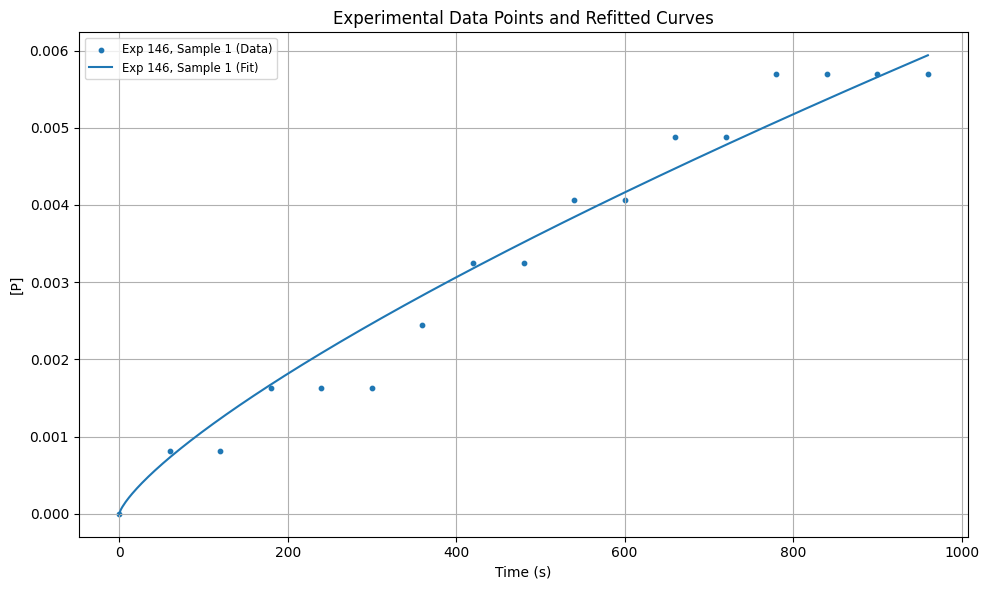

In [ ]:
plot_refitted_curves(
    dataframe=updated_df,
    time_range=(0, 1000),
    plot_title="Experimental Data Points and Refitted Curves"
)
